
# 1. Giới thiệu

### 1.1. Mục tiêu:
- Minh họa quy trình xử lý và phân tích một bộ dữ liệu thực tế
- Xây dựng và đánh giá một mô hình hồi quy tuyến tính
- Hiểu rõ về cách áp dụng các kỹ thuật data fitting trong thực tiễn
### 1.2. Bài toán: 
- Dựa trên khối lượng dữ liệu phim đồ sộ, những yếu tố quan trọng nào làm cho một bộ phim thành công hơn những bộ phim khác, hay nói cách khác là đạt điểm số IMDb cao hơn.
  
→ Đây là một ví dụ điển hình của bài toán data fitting, trong đó mục tiêu là tìm ra một hàm số phù hợp nhất để mô tả mối quan hệ giữa biến đầu ra (điểm số IMDb) và các biến đầu vào (các đặc trưng của phim).
### 1.3. Quy ước: 
Mức ý nghĩa áp dụng cho các kiểm định: alpha = 0.05

# 2. Hiểu dữ liệu
Mục đích: làm quen với bộ dữ liệu, đánh giá chất lượng dữ liệu ban đầu và khám phá các đặc điểm quan trọng trước khi tiến hành tiền xử lý dữ liệu và xây dựng mô hình.
### 2.1. Mô tả dữ liệu (Data Description)
#### 2.1.1. Nguồn dữ liệu: 
Trong Case Study này, chúng ta sử dụng bộ dữ liệu IMDB 5000 Movie Dataset lấy từ nguồn Kaggle:

https://www.kaggle.com/datasets/carolzhangdc/imdb-5000-movie-dataset

Bộ dữ liệu bao gồm 28 biến số của 5043 bộ phim, trải dài trong suốt 100 năm tại 66 quốc gia. Có 2399 tên đạo diễn phân biệt và hàng ngàn diễn viên. “imdb_score” là biến đầu ra, 27 biến còn lại là các biến đặc trưng.

Nạp dữ liệu:



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import pearsonr

%matplotlib inline
sns.set_style('whitegrid')
# Nạp dữ liệu
dataset = pd.read_csv('data/movie_metadata.csv')
dataset.head()

,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


#### 2.1.2. Mô tả dữ liệu
Kiểm tra quy mô dữ liệu

In [2]:
dataset.shape

(5043, 28)

Bộ dữ liệu gồm 5043 quan trắc (bộ phim), 28 đặc trưng (biến) mô tả đặc điểm của từng bộ phim:
- 'color': định dạng màu sắc của phim (phim màu hoặc phim trắng đen)
- 'director_name': tên đạo diễn
- 'num_critic_for_reviews': số lượng nhà phê bình đã viết đánh giá
- 'duration': thời lượng phim (tính bằng phút)
- 'director_facebook_like': số lượng thích trang facebook của đạo diễn
- 'actor_3_facebook_likes': số lượt thích trang Facebook của diễn viên phụ thứ 3
- 'actor_2_name': tên diễn viên phụ thứ 2
- 'actor_1_facebook_likes': số lượt thích trang Facebook của diễn viên chính
- 'gross': tổng doanh thu của bộ phim
- 'genres': thể loại phim (hành động, phiêu lưu, giả tưởng...)
- 'actor_1_name': tên diễn viên chính (nam/nữ diễn viên số 1)
- 'movie_title': tên bộ phim
- 'num_voted_users': số lượng khán giả đã tham gia chấm điểm/bình chọn cho phim
- 'cast_total_facebook_likes': tổng số lượt thích trên Facebook của toàn bộ dàn diễn viên
- 'actor_3_name': tên diễn viên phụ thứ 3
- 'facenumber_in_poster': số lượng khuôn mặt xuất hiện trên poster (áp phích) của phim
- 'plot_keywords': các từ khóa chính mô tả cốt truyện
- 'movie_imdb_link': đường dẫn (URL) tới trang chủ của phim trên trang web IMDB
- 'num_user_for_reviews': số lượng người dùng phổ thông đã viết bài đánh giá
- 'language': ngôn ngữ sử dụng trong phim
- 'country': quốc gia sản xuất phim
- 'content_rating': nhãn phân loại nội dung/độ tuổi khán giả (Ví dụ: PG-13, R, G...)
- 'budget': ngân sách sản xuất (tổng chi phí làm phim)
- 'title_year': năm phát hành phim
- 'actor_2_facebook_likes': số lượt thích trang Facebook của diễn viên phụ thứ 2
- 'imdb_score': điểm đánh giá trung bình của phim trên hệ thống IMDB (thang điểm 10)
- 'aspect_ratio': tỷ lệ khung hình của phim (Ví dụ: 16:9, 2.35:1)
- 'movie_facebook_likes': số lượt thích trên trang Facebook chính thức của bộ phim
=> Chọn biến mục tiêu (biến đầu ra/ biến đáp ứng) để tìm ra mô hình tốt nhất giải thích cho tổng doanh thu phim: 'imdb_score': điểm đánh giá trung bình của phim trên hệ thống IMDB (thang điểm 10)
### 2.2. Khám phá dữ liệu
#### 2.2.1. Thông tin cơ bản
Kiểm tra sơ liệu về kiểu dữ liệu và loại dữ liệu:

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [4]:
dataset.head().T

,0,1,2,3,4
color,Color,Color,Color,Color,NaN
director_name,James Cameron,Gore Verbinski,Sam Mendes,Christopher Nolan,Doug Walker
num_critic_for_reviews,723.0,302.0,602.0,813.0,NaN
duration,178.0,169.0,148.0,164.0,NaN
director_facebook_likes,0.0,563.0,0.0,22000.0,131.0
actor_3_facebook_likes,855.0,1000.0,161.0,23000.0,NaN
actor_2_name,Joel David Moore,Orlando Bloom,Rory Kinnear,Christian Bale,Rob Walker
actor_1_facebook_likes,1000.0,40000.0,11000.0,27000.0,131.0
gross,760505847.0,309404152.0,200074175.0,448130642.0,NaN
genres,Action|Adventure|Fantasy|Sci-Fi,Action|Adventure|Fantasy,Action|Adventure|Thriller,Action|Thriller,Documentary


Sau khi kiểm tra sơ liệu về bộ dữ liệu, ta nhận thấy bộ dữ liệu có một số biến sau đây:
- 'color': gồm 2 định dạng màu sắc phim: phim màu (Color) và phim trắng đen (Black and White).
- 'genres': gồm tất cả thể loại của phim ngăn cách bởi dấu |.
- 'plot_keywords': gồm các từ khóa chính mô tả cốt truyện ngăn cách bởi dấu |.

Các biến còn lại đều có kiểu dữ liệu phù hợp.

Để đảm bảo tính chất phân loại của các biến này được đưa vào mô hình một cách đúng nghĩa, giúp các thuật toán hồi quy xử lý dữ liệu chính xác hơn, ta tiến hành chuẩn hóa kiểu dữ liệu của chúng:

In [5]:
# dataset['genres'] = dataset['genres'].str.split('|').apply(tuple)
# dataset['plot_keywords'] = dataset['plot_keywords'].str.split('|').apply(tuple)
dataset['color'] = dataset['color'].astype('category')

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   color                      5024 non-null   category
 1   director_name              4939 non-null   object  
 2   num_critic_for_reviews     4993 non-null   float64 
 3   duration                   5028 non-null   float64 
 4   director_facebook_likes    4939 non-null   float64 
 5   actor_3_facebook_likes     5020 non-null   float64 
 6   actor_2_name               5030 non-null   object  
 7   actor_1_facebook_likes     5036 non-null   float64 
 8   gross                      4159 non-null   float64 
 9   genres                     5043 non-null   object  
 10  actor_1_name               5036 non-null   object  
 11  movie_title                5043 non-null   object  
 12  num_voted_users            5043 non-null   int64   
 13  cast_total_facebook_likes  5043 n

In [7]:
dataset.head().T

,0,1,2,3,4
color,Color,Color,Color,Color,NaN
director_name,James Cameron,Gore Verbinski,Sam Mendes,Christopher Nolan,Doug Walker
num_critic_for_reviews,723.0,302.0,602.0,813.0,NaN
duration,178.0,169.0,148.0,164.0,NaN
director_facebook_likes,0.0,563.0,0.0,22000.0,131.0
actor_3_facebook_likes,855.0,1000.0,161.0,23000.0,NaN
actor_2_name,Joel David Moore,Orlando Bloom,Rory Kinnear,Christian Bale,Rob Walker
actor_1_facebook_likes,1000.0,40000.0,11000.0,27000.0,131.0
gross,760505847.0,309404152.0,200074175.0,448130642.0,NaN
genres,Action|Adventure|Fantasy|Sci-Fi,Action|Adventure|Fantasy,Action|Adventure|Thriller,Action|Thriller,Documentary


Về giá trị dữ liệu:
- Giá trị của các biến trong bộ dữ liệu có sự chênh lệch lớn giữa các biến.

#### 2.2.2. Kiểm tra chất lượng dữ liệu
Để đánh giá chất lượng dữ liệu, ta tiến hành kiểm tra xem dữ liệu có trùng lắp (duplicate), có khuyết (missing), có nhiễu (noise), có mâu thuẫn (conflict) hay không.

**Kiểm tra dữ liệu có trùng lắp (duplicate):**

In [8]:
print(dataset.duplicated().sum())

45


Ta thấy bộ dữ liệu có 45 dữ liệu trùng lắp.

**Kiểm tra dữ liệu khuyết (missing)**

In [9]:
dataset.isnull().sum()

color                         19
director_name                104
num_critic_for_reviews        50
duration                      15
director_facebook_likes      104
actor_3_facebook_likes        23
actor_2_name                  13
actor_1_facebook_likes         7
gross                        884
genres                         0
actor_1_name                   7
movie_title                    0
num_voted_users                0
cast_total_facebook_likes      0
actor_3_name                  23
facenumber_in_poster          13
plot_keywords                153
movie_imdb_link                0
num_user_for_reviews          21
language                      14
country                        5
content_rating               303
budget                       492
title_year                   108
actor_2_facebook_likes        13
imdb_score                     0
aspect_ratio                 329
movie_facebook_likes           0
dtype: int64

Ta thấy bộ dữ liệu có:

- 19 giá trị khuyết của biến "color"
- 104 giá trị khuyết của biến "director_name"
- 50 giá trị khuyết của biến "num_critic_for_reviews"
- 15 giá trị khuyết của biến "duration"
- 104 giá trị khuyết của biến "director_facebook_likes"
- 23 giá trị khuyết của biến "actor_3_facebook_likes"
- 13 giá trị khuyết của biến "actor_2_name"
- 7 giá trị khuyết của biến "actor_1_facebook_likes"
- 884 giá trị khuyết của biến "gross"
- 7 giá trị khuyết của biến "actor_1_name"
- 23 giá trị khuyết của biến "actor_3_name"
- 13 giá trị khuyết của biến "facenumber_in_poster"
- 153 giá trị khuyết của biến "plot_keywords"
- 21 giá trị khuyết của biến "num_user_for_reviews"
- 14 giá trị khuyết của biến "language"
- 5 giá trị khuyết của biến "country"
- 303 giá trị khuyết của biến "content_rating"
- 492 giá trị khuyết của biến "budget"
- 108 giá trị khuyết của biến "title_year"
- 13 giá trị khuyết của biến "actor_2_facebook_likes"
- 329 giá trị khuyết của biến "aspect_ratio"

Ta nhận thấy: Tập dữ liệu có tối đa 5043 dòng, tuy nhiên rất nhiều biến bị khuyết dữ liệu. Đặc biệt là hai biến tài chính: "gross" (doanh thu) chỉ có 4159 giá trị và "budget" (ngân sách) chỉ có 4551 giá trị. Điều này cần được xử lý kỹ (điền khuyết hoặc loại bỏ) trước khi đưa vào mô hình.

**Kiểm tra dữ liệu nhiễu (noise):**

Trước tiên ta xem xét các thống kê mô tả của từng biến numeric trong bộ dữ liệu:

In [10]:
dataset.describe().T


,count,mean,std,min,25%,50%,75%,max
num_critic_for_reviews,4993.0,1.401943e+02,1.216017e+02,1.00,50.00,110.00,195.00,8.130000e+02
duration,5028.0,1.072011e+02,2.519744e+01,7.00,93.00,103.00,118.00,5.110000e+02
director_facebook_likes,4939.0,6.865092e+02,2.813329e+03,0.00,7.00,49.00,194.50,2.300000e+04
actor_3_facebook_likes,5020.0,6.450098e+02,1.665042e+03,0.00,133.00,371.50,636.00,2.300000e+04
actor_1_facebook_likes,5036.0,6.560047e+03,1.502076e+04,0.00,614.00,988.00,11000.00,6.400000e+05
gross,4159.0,4.846841e+07,6.845299e+07,162.00,5340987.50,25517500.00,62309437.50,7.605058e+08
num_voted_users,5043.0,8.366816e+04,1.384853e+05,5.00,8593.50,34359.00,96309.00,1.689764e+06
cast_total_facebook_likes,5043.0,9.699064e+03,1.816380e+04,0.00,1411.00,3090.00,13756.50,6.567300e+05
facenumber_in_poster,5030.0,1.371173e+00,2.013576e+00,0.00,0.00,1.00,2.00,4.300000e+01
num_user_for_reviews,5022.0,2.727708e+02,3.779829e+02,1.00,65.00,156.00,326.00,5.060000e+03


Ta nhận thấy:

- Biến "duration" (thời lượng) có min = 7 phút và max = 511 phút. Dù hơi lớn nhưng vẫn nằm trong khoảng hợp lý của thực tế (phim ngắn hoặc các phim tài liệu cực dài).
- Rất nhiều biến như "director_facebook_likes", các biến "actor_facebook_likes", "movie_facebook_likes" và "facenumber_in_poster" có giá trị min = 0. Điều này hợp lý (do không dùng mạng xã hội hoặc poster phong cảnh) nhưng sẽ gây khó khăn nếu cần biến đổi biến.
- Biến “budget” có giá trị lớn nhất (max) cực kỳ cao (lên tới $1.22 \times 10^{10}$, tức khoảng 12 tỷ). Mức này chênh lệch vô cùng lớn so với phân vị 75% (chỉ 45 triệu). Điều này cho thấy biến này có chứa các giá trị ngoại lai rất nặng, hoặc dữ liệu bị lẫn lộn đơn vị tiền tệ (ví dụ: tiền Won Hàn Quốc, tiền Yên Nhật) thay vì chỉ dùng USD. Ta có thể sẽ xem đó là nhiễu hoặc cần quy đổi lại.
- Biến “title_year” có khoảng giá trị [1916, 2016], phản ánh đúng khoảng thời gian phát hành phim hợp lý.
- Biến “imdb_score” có giá trị trong khoảng [1.60, 9.50]. Điều này hoàn toàn hợp lý vì điểm IMDB nằm trên thang điểm [0, 10].
- Nhìn chung, tất cả các biến đều có dữ liệu hợp lệ, ngoại trừ việc bị khuyết ở nhiều cột và dấu hiệu sai lệch đơn vị ở biến tài chính thì không phát hiện các giá trị bất thường vi phạm ràng buộc miền giá trị.
- Ta sẽ kiểm tra boxplot của từng biến để xem dữ liệu ngoại lai (outlier) thế nào:

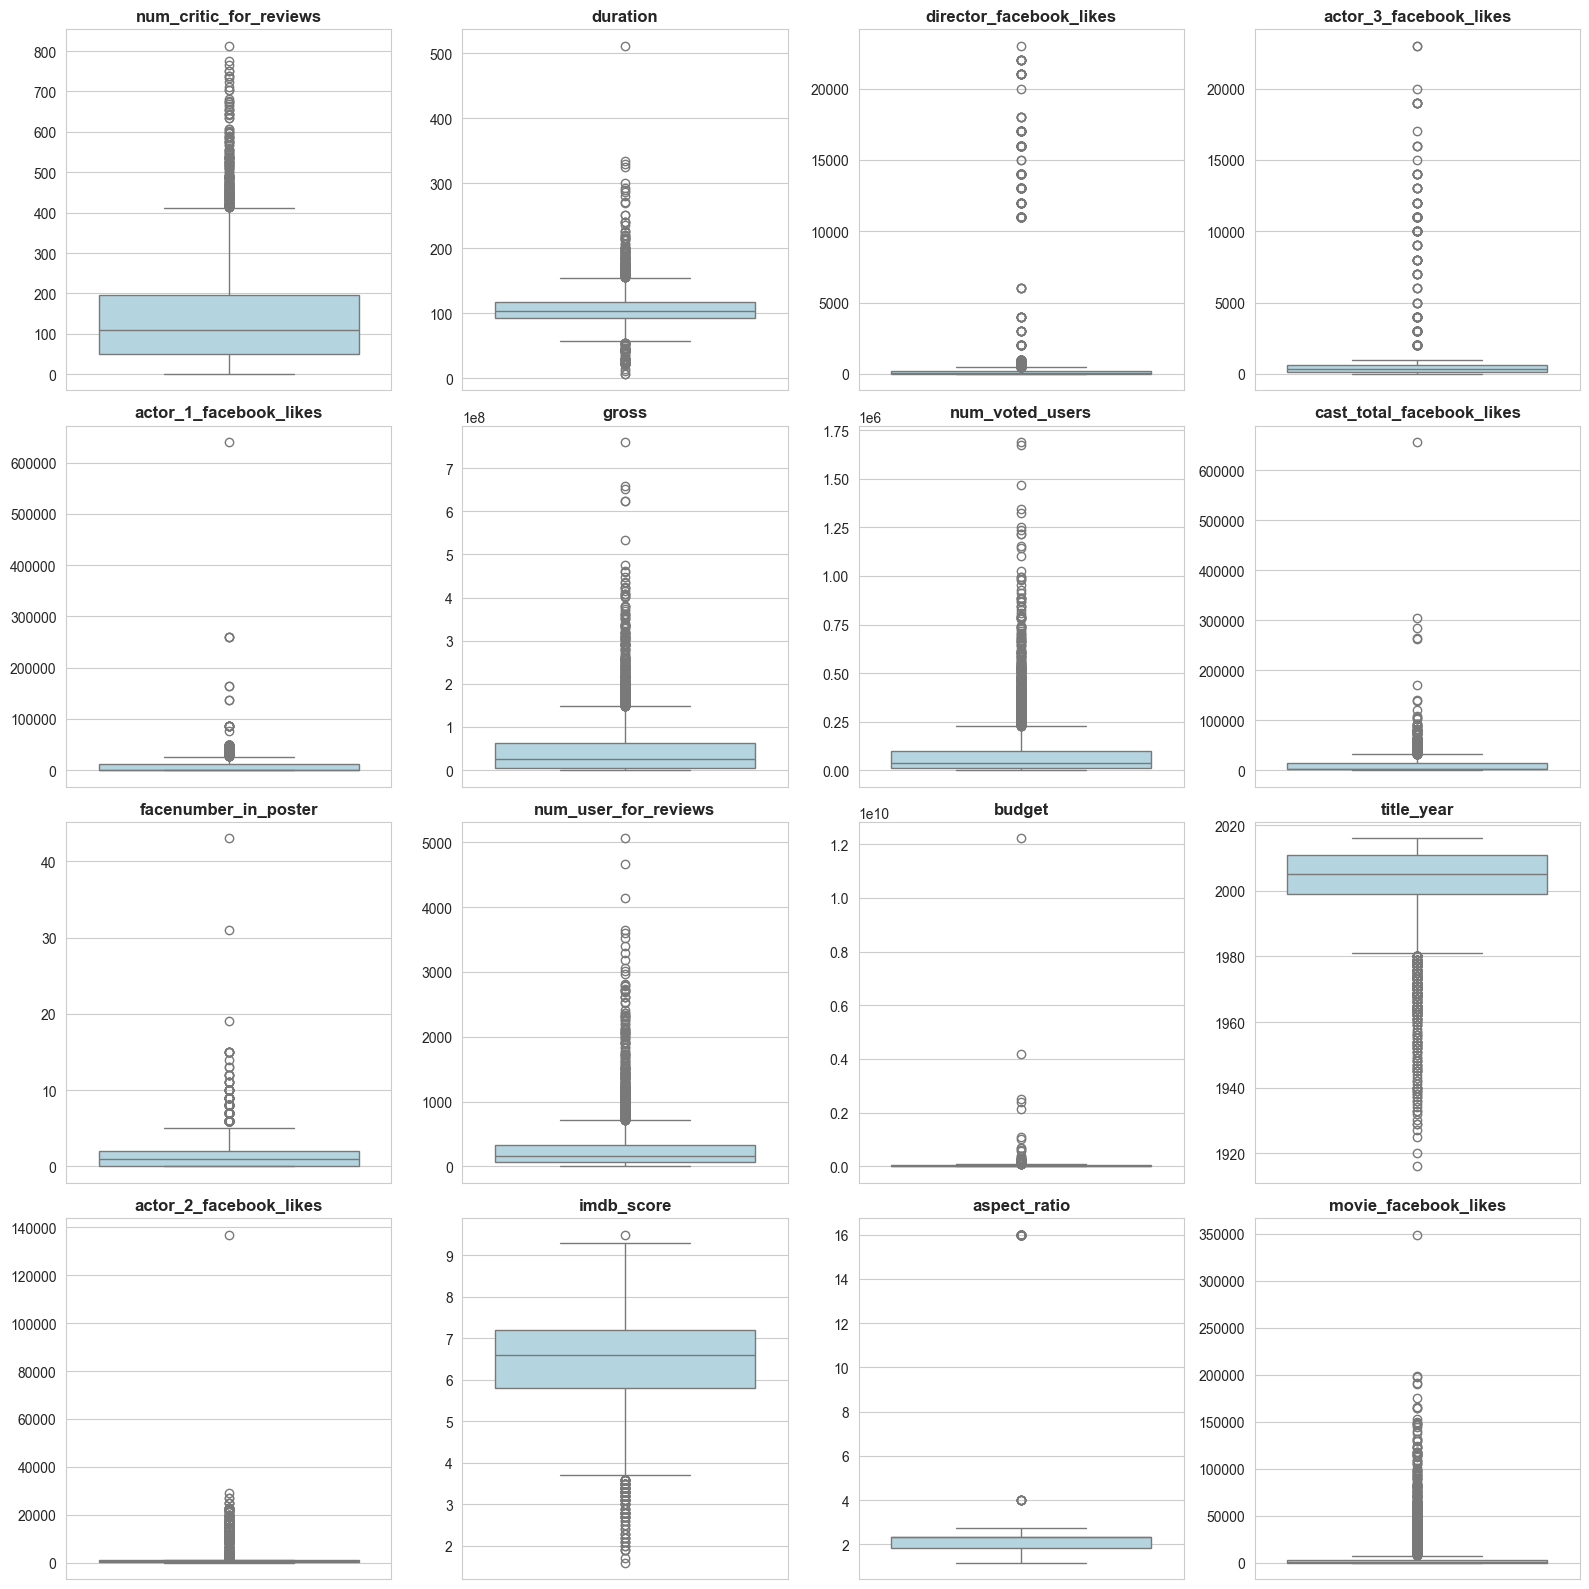

In [11]:
cols = ['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 
        'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 
        'title_year', 'actor_2_facebook_likes', 'imdb_score', 'aspect_ratio', 'movie_facebook_likes']

# Tạo một tấm khung lớn chứa 4 hàng, 4 cột (tổng cộng 16 ô)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 16))

# Trải phẳng lưới 4x4 thành một mảng 1 chiều để dễ lặp qua
axes = axes.flatten()

# Lặp qua từng cột và từng ô vẽ (axis)
for i, col in enumerate(cols):
    sns.boxplot(y=dataset[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('') # Tắt tên trục y để tổng thể không bị rối mắt

# Tự động căn chỉnh khoảng cách giữa 16 biểu đồ để chữ không đè lên nhau
plt.tight_layout()
plt.show()

Từ hình ảnh boxplot, ta thấy tất cả các biến có rất nhiều outlier.

**Kiểm tra dữ liệu mâu thuẫn (conflict)**

Như đã nhận xét ở phần kiểm tra noise data, các biến đều có dữ liệu hợp lệ, không phát hiện các giá trị bất thường vi phạm ràng buộc miền giá trị của từng biến.

Ta sẽ kiểm tra xem liệu có trường hợp mâu thuẫn về mặt logic thông thường hay không.

- Trường hợp lượt thích trang Facebook của 1 diễn viên chính lại lớn hơn tổng số lượt thích của toàn bộ dàn diễn viên cộng lại:


In [12]:
len(dataset[dataset['actor_1_facebook_likes'] > dataset['cast_total_facebook_likes']])

0

- Trường hợp phim không có khán giả nào bình chọn nhưng lại có điểm đánh giá trung bình:

In [13]:
len(dataset[(dataset['num_voted_users'] == 0) & (dataset['imdb_score'] > 0)])

0

- Trường hợp phim có ngân sách sản xuất (budget) hoặc doanh thu (gross) mang giá trị âm

In [14]:
len(dataset[(dataset['budget'] < 0) | (dataset['gross'] < 0)])

0

Ta kiểm tra suy rộng hơn một chút:

- Trường hợp phim được đánh giá là kiệt tác (Điểm imdb_score $\ge$ 8) nhưng doanh thu phòng vé lại thảm họa (Gross < 50,000 USD):

In [15]:
display_cols = ['movie_title', 'title_year', 'imdb_score', 'genres', 'gross', 
                'budget', 'duration', 'num_voted_users', 'director_name']

check_4 = dataset[(dataset['imdb_score'] >= 8) & (dataset['gross'] < 50000)]
# Sắp xếp theo điểm số giảm dần để giống báo cáo
check_4 = check_4.sort_values(by='imdb_score', ascending=False)
display(check_4[display_cols].head(5)) # Dùng hàm display() trong Jupyter để in bảng đẹp

,movie_title,title_year,imdb_score,genres,gross,budget,duration,num_voted_users,director_name
2425,Raging Bull,1980.0,8.3,Biography|Drama|Sport,45250.0,18000000.0,121.0,235133,Martin Scorsese
2734,Metropolis,1927.0,8.3,Drama|Sci-Fi,26435.0,6000000.0,145.0,111841,Fritz Lang
3643,Lake of Fire,2006.0,8.3,Documentary,23807.0,NaN,152.0,2143,Tony Kaye
3553,Elite Squad,2007.0,8.1,Action|Crime|Drama|Thriller,8060.0,4000000.0,115.0,81644,José Padilha
4838,Nothing But a Man,1964.0,8.1,Drama|Romance,12438.0,160000.0,95.0,891,Michael Roemer


- Trường hợp phim bị khán giả và giới phê bình chê thậm tệ (Điểm imdb_score $\le$ 4.5) nhưng doanh thu lại cao kỷ lục (Gross > 100,000,000 USD):

In [16]:
check_5 = dataset[(dataset['imdb_score'] <= 4.5) & (dataset['gross'] > 100000000)]
check_5 = check_5.sort_values(by='imdb_score', ascending=False)
display(check_5[display_cols])

,movie_title,title_year,imdb_score,genres,gross,budget,duration,num_voted_users,director_name
597,Alvin and the Chipmunks: The Squeakquel,2009.0,4.5,Animation|Comedy|Family|Fantasy|Music,219613391.0,75000000.0,88.0,31649,Betty Thomas
448,Alvin and the Chipmunks: Chipwrecked,2011.0,4.4,Adventure|Animation|Comedy|Family|Fantasy|Music,133103929.0,75000000.0,87.0,22838,Mike Mitchell
426,Nutty Professor II: The Klumps,2000.0,4.3,Comedy|Romance|Sci-Fi,123307945.0,65000000.0,109.0,39391,Peter Segal
140,The Last Airbender,2010.0,4.2,Action|Adventure|Family|Fantasy,131564731.0,150000000.0,103.0,118951,M. Night Shyamalan
1190,Fifty Shades of Grey,2015.0,4.1,Drama|Romance,166147885.0,40000000.0,129.0,220020,Sam Taylor-Johnson
1191,Spy Kids 3-D: Game Over,2003.0,4.1,Action|Adventure|Comedy|Family|Sci-Fi,111760631.0,38000000.0,84.0,40227,Robert Rodriguez
273,The Cat in the Hat,2003.0,3.8,Adventure|Comedy|Family|Fantasy,100446895.0,109000000.0,82.0,36033,Bo Welch
217,Batman & Robin,1997.0,3.7,Action,107285004.0,125000000.0,125.0,189855,Joel Schumacher


Ta thấy bộ dữ liệu không có dữ liệu mâu thuẫn. Có 13 quan trắc cho thấy mối quan hệ không phù hợp với logic thông thường của thị trường, chẳng hạn như các bộ phim được đánh giá vô cùng cao nhưng lại thất bại hoàn toàn về doanh thu phòng vé, hoặc ngược lại bị chê tơi tả nhưng lại thành công rực rỡ về mặt thương mại.

#### 2.2.3. Kiểm tra phân phối


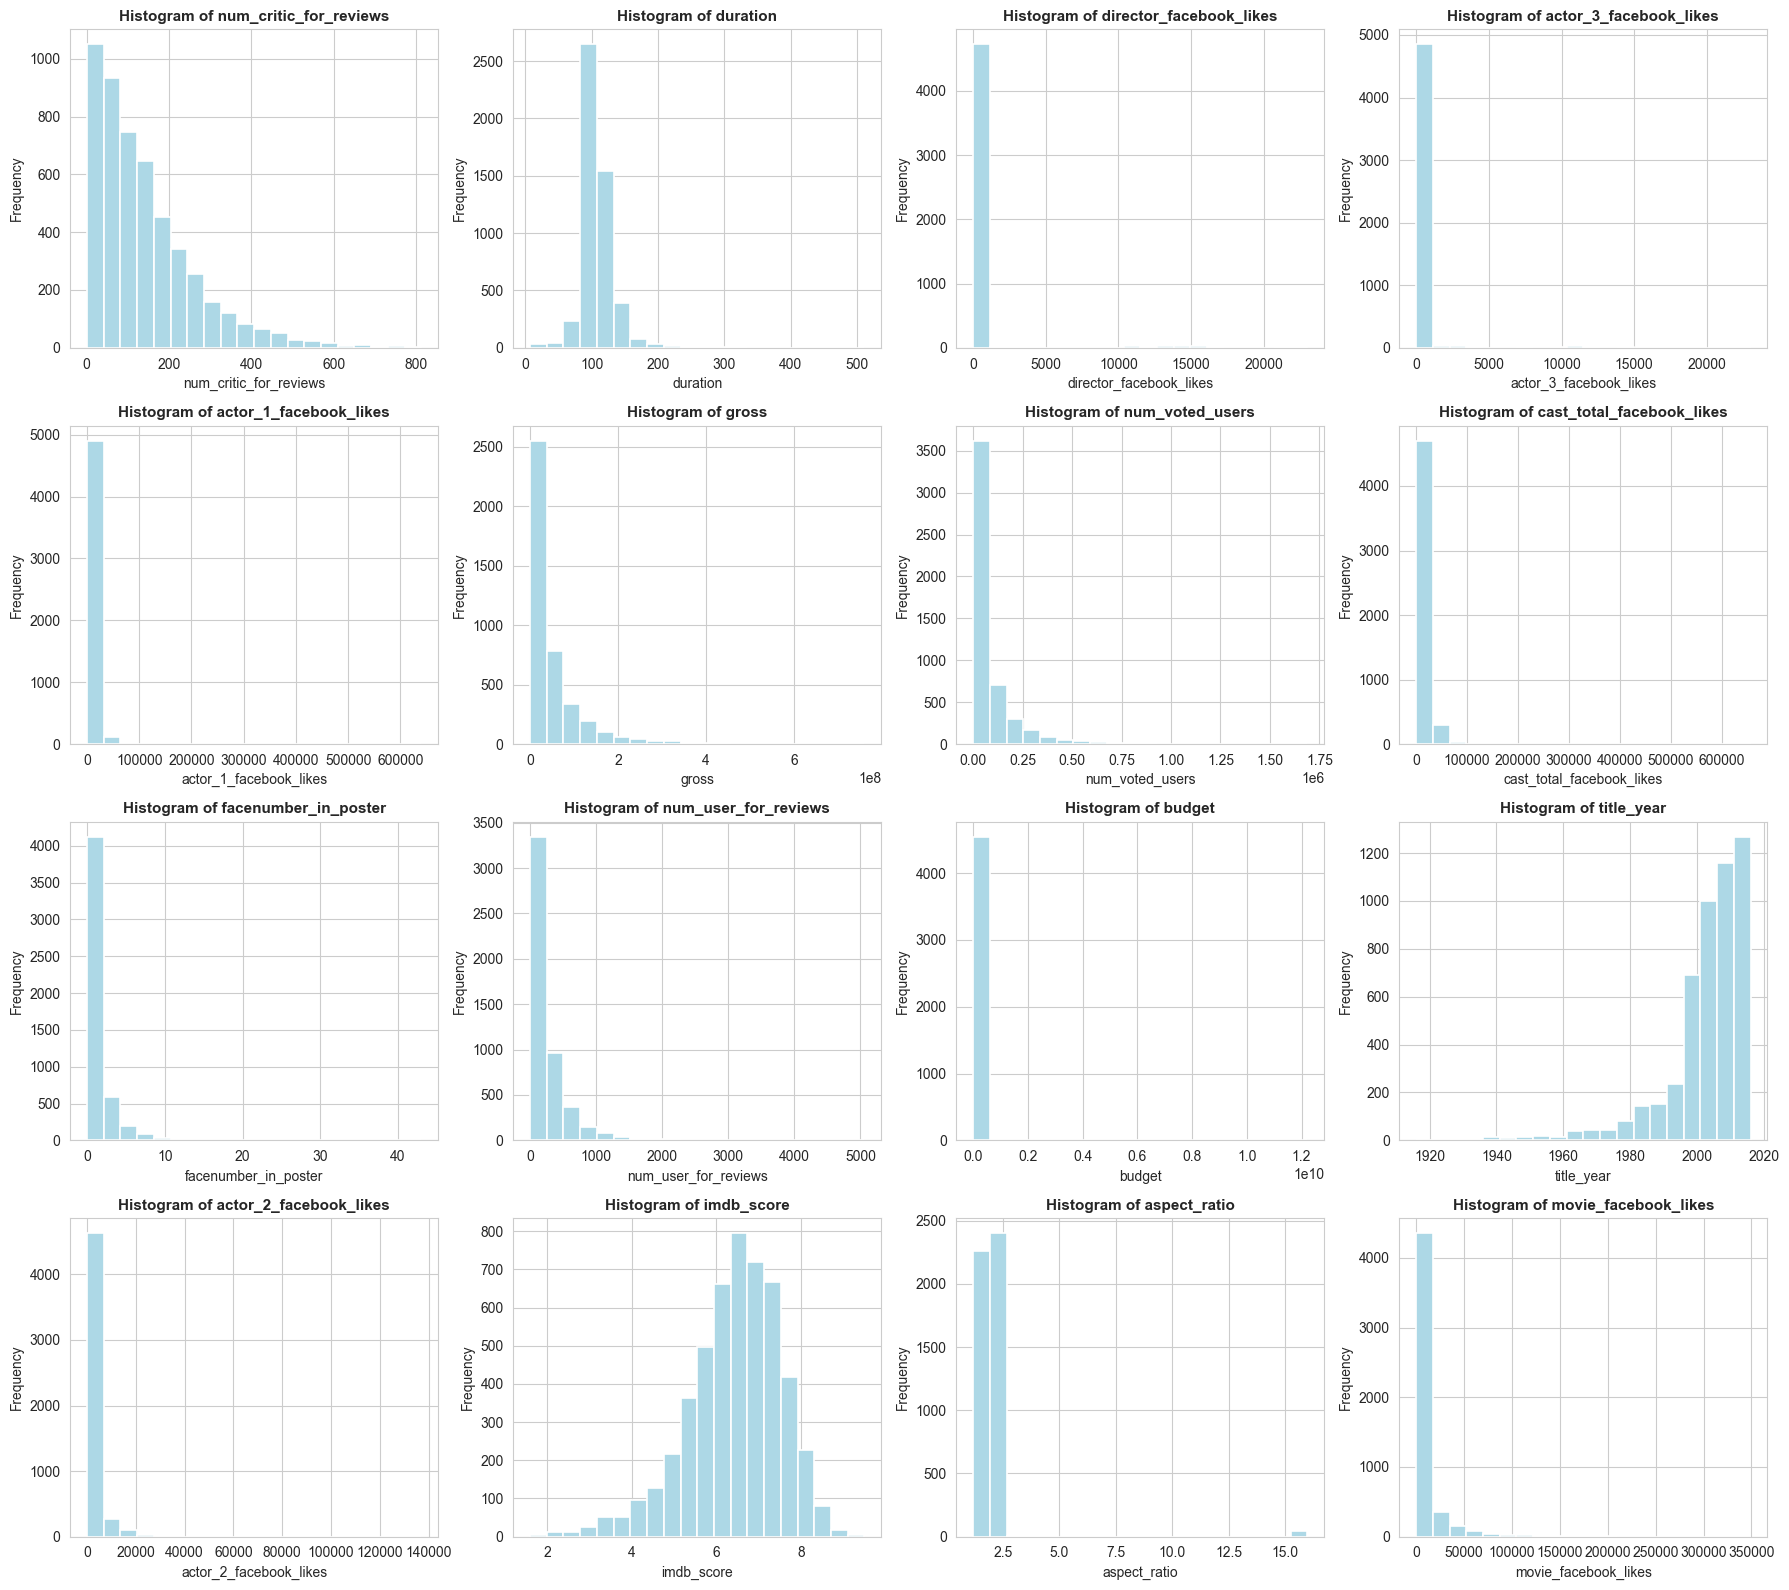

In [17]:
# Tạo khung ảnh lớn chứa 16 biểu đồ (4 hàng x 4 cột)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 16))

# Trải phẳng mảng 2D thành 1D để dễ dùng vòng lặp
axes = axes.flatten()

for i, col in enumerate(cols):
    data_to_plot = dataset[col]
    
    # Vẽ Histogram mô phỏng R
    axes[i].hist(
        data_to_plot, 
        bins=20,                 # Chia thành 20 cột (có thể tăng/giảm tùy ý)
        color='lightblue',       # Màu xanh nhạt giống ảnh
        edgecolor='white',       # Viền trắng giữa các cột
        linewidth=1.2            # Độ dày của viền trắng
    )
    
    # Thêm tiêu đề và nhãn trục
    axes[i].set_title(f'Histogram of {col}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

# Căn chỉnh tự động để chữ không đè lên nhau
plt.tight_layout()
plt.show()

Từ các biểu đồ histogram, ta thấy:

- Biến “imdb_score” có phân phối chuẩn/ gần chuẩn (đồ thị hình quả chuông đối xứng rõ rệt). Biến "duration" cũng có phân phối tập trung quanh giá trị trung bình (khoảng 100 phút) nhưng có đuôi hơi lệch sang phải.
- Hầu hết các biến đếm, tài chính và tương tác mạng xã hội bao gồm “num_critic_for_reviews”, “gross”, “budget”, “num_voted_users”, “num_user_for_reviews”, “facenumber_in_poster” và toàn bộ các biến lượt likes Facebook (director, actor_1/2/3, cast_total, movie) đều có phân phối lệch phải rất mạnh (right-skewed). Dữ liệu tập trung ở mức giá trị thấp và kéo đuôi rất dài về bên phải.
- Biến “title_year” có phân phối lệch trái (left-skewed), cho thấy phần lớn các bộ phim trong tập dữ liệu này được sản xuất trong khoảng thời gian gần đây (từ những năm 1990 trở lại đây).
- Biến “aspect_ratio” có phân phối chia thành 1-2 cụm tập trung cao đột biến, điều này cho thấy tỷ lệ khung hình phim chỉ xoay quanh một vài chuẩn điện ảnh phổ biến (như 1.85 hoặc 2.35) chứ không phải là một dải giá trị liên tục.
- Riêng biến "budget" gần như chỉ hiển thị một cột duy nhất. Điều này cho thấy sự tồn tại của các giá trị nhiễu vô cùng lớn đã làm biến dạng hoàn toàn thang đo của trục hoành.

Từ phân phối của các biến, dự đoán rằng có lẽ ta cần phải thực hiện phép biến đổi biến trên phần lớn các biến, đặc biệt là nhóm biến lệch phải, để đưa chúng về dạng gần chuẩn hơn. Đồng thời, cần có biện pháp xử lý nhiễu cho biến budget.

#### 2.2.4. Phân tích quan hệ giữa các biến

<Figure size 2000x2000 with 0 Axes>

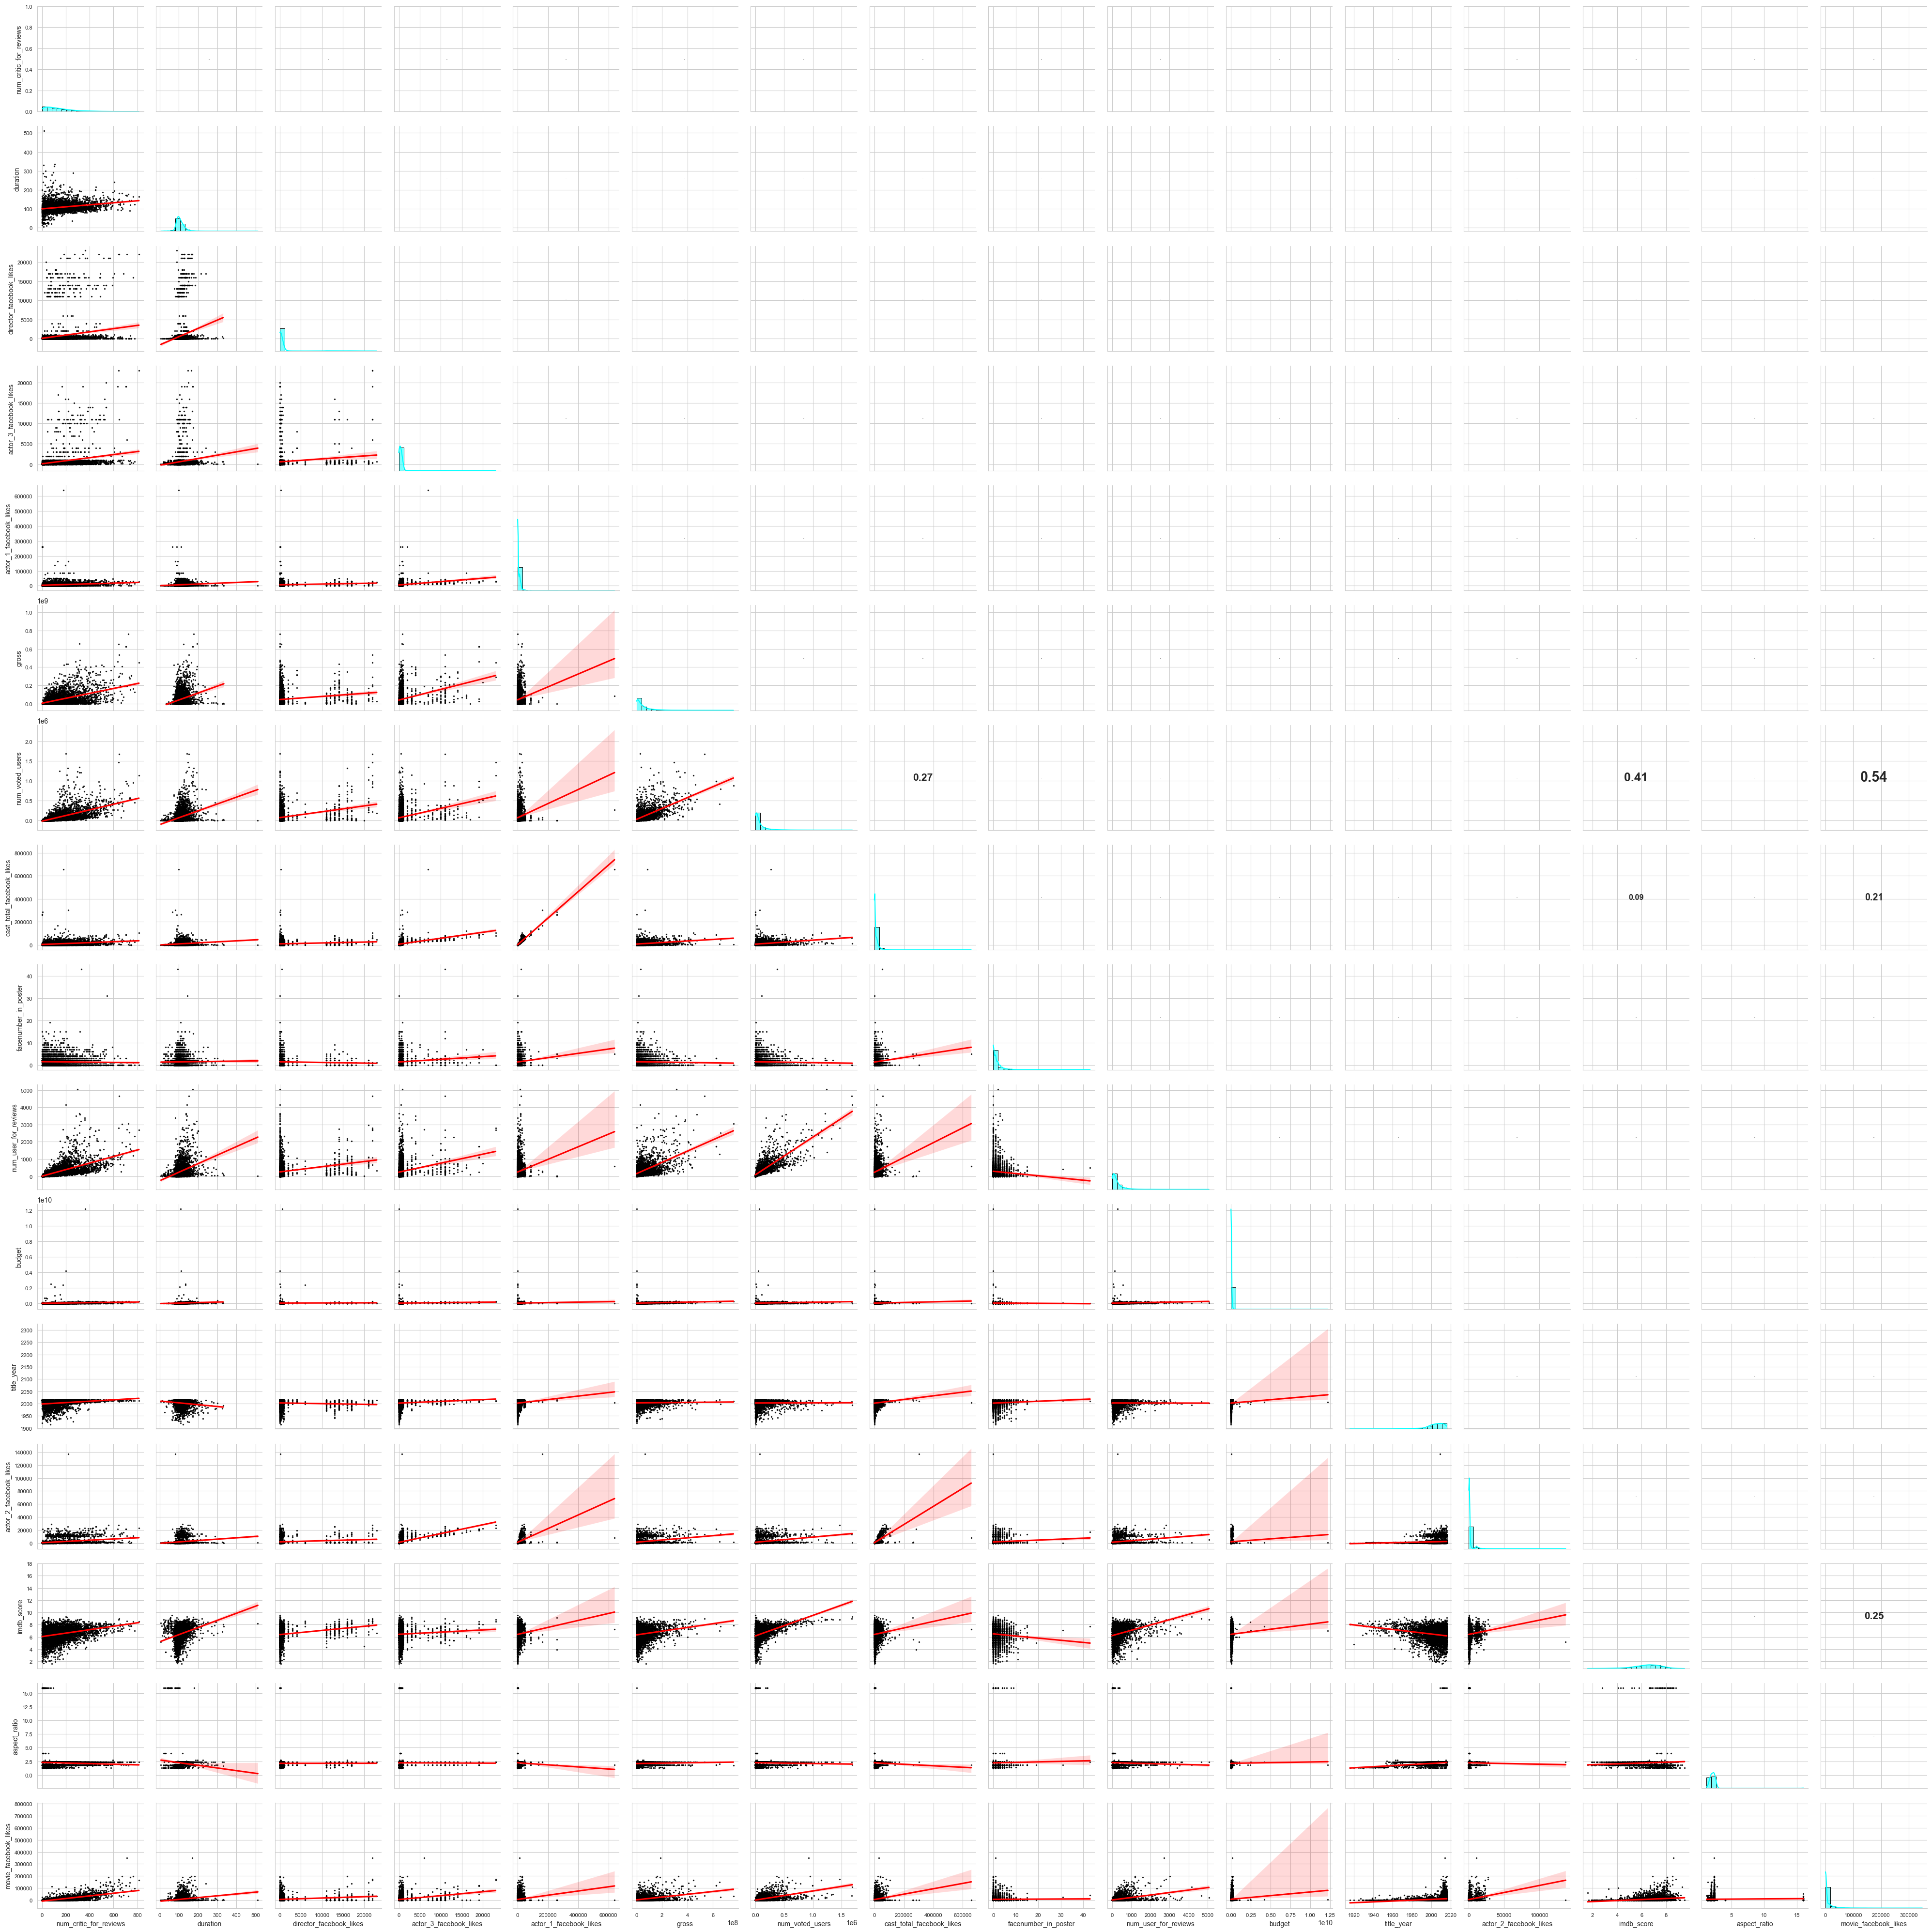

In [18]:
data = dataset[cols]
# Hàm này sẽ tính và in con số tương quan lên góc trên bên phải của ma trận (giống R)
def corrfunc(x, y, **kws):
    r, _ = pearsonr(x, y)
    ax = plt.gca()
    # Phóng to font chữ dựa trên độ lớn của r (tùy chọn)
    font_size = abs(r) * 20 + 10 
    ax.annotate(f"{r:.2f}", xy=(.5, .5), xycoords=ax.transAxes,
                horizontalalignment='center', verticalalignment='center',
                fontsize=font_size, fontweight='bold')

# --- 3. VẼ MA TRẬN TƯƠNG QUAN ---
plt.figure(figsize=(20, 20)) # Khung hình phải cực lớn để chứa 16x16 ô

# Sử dụng PairGrid của Seaborn
g = sns.PairGrid(data)

# ĐƯỜNG CHÉO: Vẽ Histogram kết hợp đường cong mật độ (KDE) màu xanh nhạt
g.map_diag(sns.histplot, kde=True, color='cyan', bins=20, edgecolor='black')

# NỬA DƯỚI ĐƯỜNG CHÉO: Vẽ Scatterplot với chấm đen nhỏ và đường xu hướng (regplot) màu đỏ
g.map_lower(sns.regplot, scatter_kws={'color': 'black', 's': 2}, line_kws={'color': 'red'})

# NỬA TRÊN ĐƯỜNG CHÉO: Hiển thị hệ số tương quan (chạy hàm corrfunc đã định nghĩa ở trên)
g.map_upper(corrfunc)

# Điều chỉnh lại kích thước chữ trên trục tọa độ để không bị rối
for ax in g.axes.flatten():
    ax.tick_params(axis='both', labelsize=8)
    ax.xaxis.label.set_size(10)
    ax.yaxis.label.set_size(10)

plt.tight_layout()
plt.show()

Hoặc:

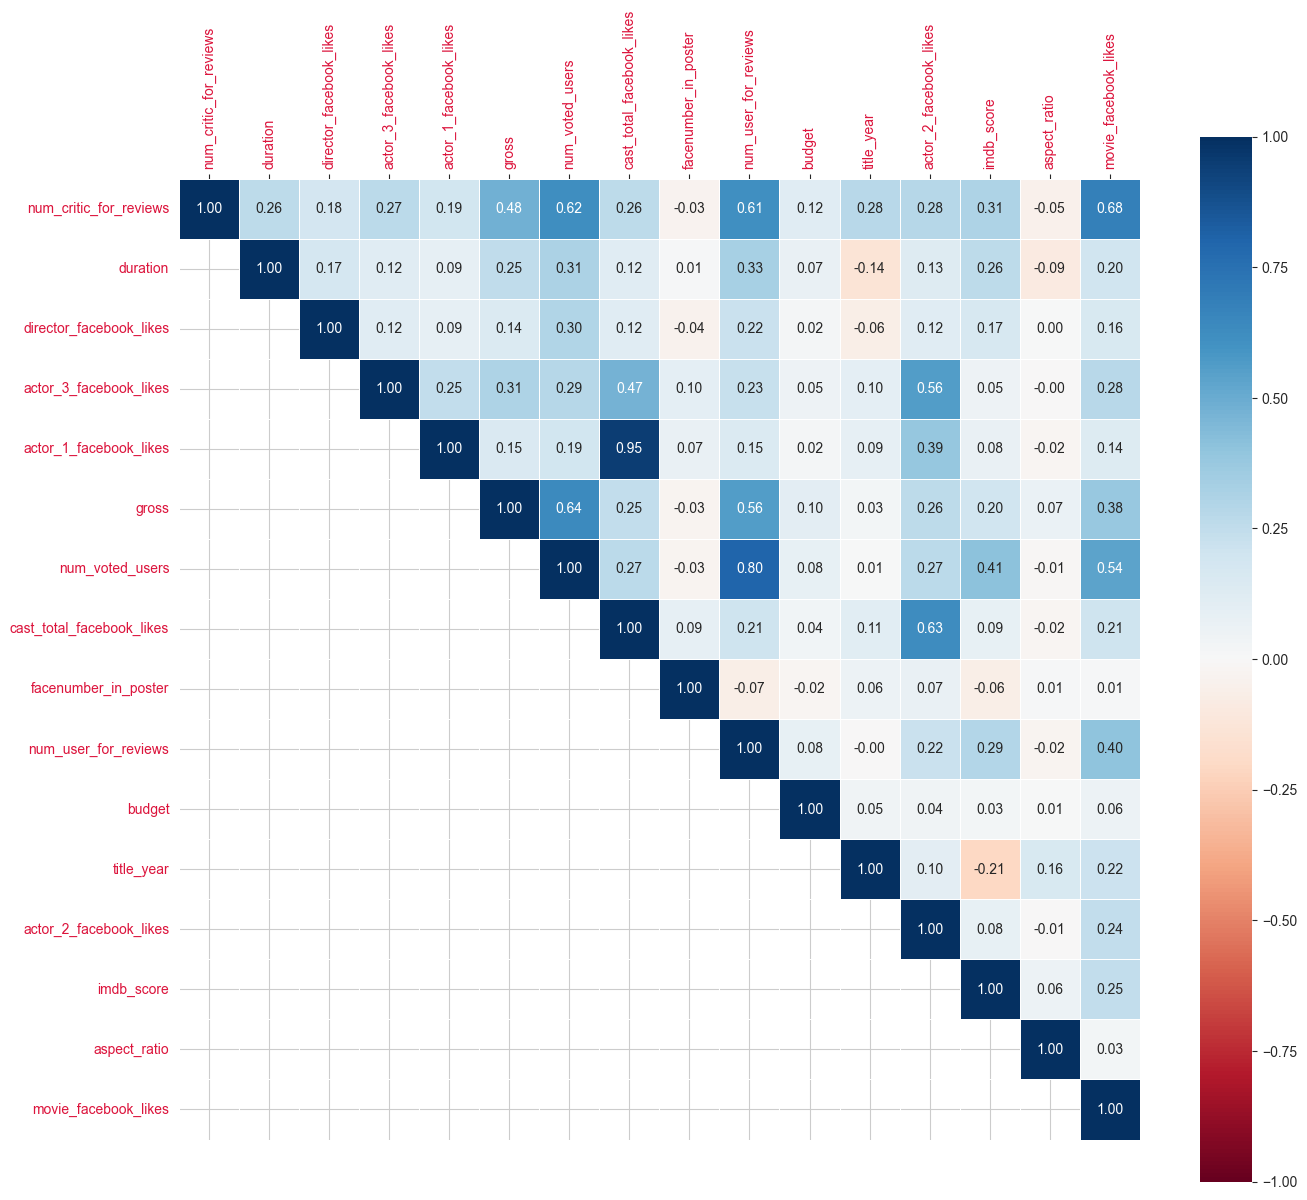

In [19]:
# 2. Tính ma trận tương quan (Correlation Matrix)
corr = dataset[cols].corr()

# 3. Tạo mặt nạ (mask) để ẩn nửa dưới của ma trận (chỉ lấy tam giác trên)
# np.tril sẽ lấy phần dưới đường chéo, ta dùng nó làm mask che đi
mask = np.tril(np.ones_like(corr, dtype=bool), k=-1)

# 4. Thiết lập khung vẽ
# Phải để kích thước lớn (14x14) vì 16 biến vẽ ra sẽ rất chật
plt.figure(figsize=(14, 14))

# 5. Vẽ Heatmap
ax = sns.heatmap(
    corr, 
    mask=mask,               # Áp dụng mặt nạ ẩn nửa dưới
    cmap='RdBu',             # Thang màu Đỏ (Red) - Xanh (Blue) giống ảnh
    vmin=-1, vmax=1,         # Cố định thang đo từ -1 đến 1
    center=0,                # Điểm 0 là màu trắng
    annot=True,              # Hiển thị con số
    fmt=".2f",               # Làm tròn 2 chữ số thập phân (vd: 0.38)
    square=True,             # Ép các ô thành hình vuông
    linewidths=0.5,          # Đường viền trắng mỏng giữa các ô
    cbar_kws={"shrink": 0.8} # Thu nhỏ thanh màu bên phải một chút cho cân đối
)

# 6. Tinh chỉnh trục tọa độ và màu chữ để giống hệt ảnh mẫu
# Đưa trục X lên trên đỉnh
ax.xaxis.tick_top()

# Xoay chữ trục X 90 độ cho dễ đọc
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Đổi màu chữ của các nhãn (Labels) sang màu Đỏ (crimson)
for label in ax.get_xticklabels():
    label.set_color("crimson")
for label in ax.get_yticklabels():
    label.set_color("crimson")

# Căn chỉnh bố cục và hiển thị
plt.tight_layout()
plt.show()

Từ ma trận tương quan giữa các biến, ta nhận thấy:

- Biến “imdb_score” (số điểm) có tương quan thuận tương đối mạnh với các biến tương tác của khán giả là “num_voted_users” và “num_user_for_reviews” với hệ số tương quan lần lượt là 0.41 và 0.29. Điều này cho thấy mức độ quan tâm và đánh giá của cộng đồng mạng tỷ lệ thuận với số điểm của phim. Qua đây ta cũng dự đoán sự hiện diện của các biến này có vai trò quan trọng trong mô hình dự báo số điểm phim.
- Biến “actor_1_facebook_likes” và “cast_total_facebook_likes” có hệ số tương quan cực kỳ cao lên tới 0.95 (gần như tuyệt đối). Điều này hoàn toàn logic vì lượt thích của diễn viên chính thường chiếm phần lớn tổng số lượt thích của cả dàn diễn viên. Việc giữ lại cả 2 biến này trong mô hình sẽ rất dễ dẫn đến hiện tượng đa cộng tuyến (multicollinearity).
- Biến “num_voted_users” và “num_user_for_reviews” cũng có tương quan thuận và rất chặt với nhau với hệ số tương quan là 0.80. Điều này cũng có thể dẫn đến đa cộng tuyến.
- Các cặp biến liên quan đến diễn viên phụ như “actor_2_facebook_likes” - “cast_total_facebook_likes” (0.63), hay cặp “num_critic_for_reviews” - “movie_facebook_likes” (0.68) có hệ số tương quan từ trung bình đến khá, cho thấy chúng có sự đồng biến nhất định.
- Khác với các quy luật thông thường, biến “budget” (ngân sách) trong tập dữ liệu này lại có tương quan rất yếu với “imdb_score” (chỉ đạt 0.03). Các biến như “facenumber_in_poster” (-0.06), “aspect_ratio” (0.06) hầu như không có tương quan với “imdb_score”. Có thể dự đoán các biến này đóng góp rất ít vào hiệu suất của mô hình dự báo số điểm phim.

**Kiểm tra đa cộng tuyến**

In [20]:
from sklearn.impute import SimpleImputer # Bổ sung công cụ điền khuyết

X_raw = dataset[cols]

# ---------------------------------------------------------
# 2. XỬ LÝ NaN BẰNG CÁCH ĐIỀN KHUYẾT (Thay vì dùng dropna)
# ---------------------------------------------------------
# Khởi tạo công cụ điền khuyết. Ở đây ta dùng chiến lược điền bằng giá trị Trung bình ('mean').
# Bạn có thể đổi strategy='median' nếu muốn dùng Trung vị.
imputer = SimpleImputer(strategy='mean')

# Áp dụng điền khuyết và chuyển lại thành DataFrame
# X_imputed lúc này là một ma trận đặc 100%, không còn bất kỳ giá trị NaN nào
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)


# 3. Tính VIF bằng hàm tự xây dựng
from part1utils.metrics import vif
from summary_utils import add_constant, dataframe_to_matrix

def calculate_vif_custom(df):
    df_const = add_constant(df)
    X_matrix = dataframe_to_matrix(df_const)
    vif_values = vif(X_matrix)
    vif_df = pd.DataFrame({
        'Biến số (Variables)': df.columns,
        'VIF': vif_values
    })
    return vif_df.sort_values(by="VIF", ascending=False).reset_index(drop=True)


# 4. Chạy hàm với dữ liệu X_imputed (Đã được điền khuyết)
vif_data_custom = calculate_vif_custom(X_imputed)

print(vif_data_custom)

          Biến số (Variables)         VIF
0   cast_total_facebook_likes  299.270598
1      actor_1_facebook_likes  206.201275
2      actor_2_facebook_likes   16.807017
3      actor_3_facebook_likes    7.127722
4             num_voted_users    4.152888
5        num_user_for_reviews    3.209081
6      num_critic_for_reviews    2.873496
7        movie_facebook_likes    2.094568
8                       gross    1.779129
9                  imdb_score    1.400634
10                 title_year    1.302716
11                   duration    1.201212
12    director_facebook_likes    1.117636
13               aspect_ratio    1.043627
14       facenumber_in_poster    1.035095
15                     budget    1.020356


Từ hệ số phóng đại VIF, ta thấy có hiện tượng đa cộng tuyến rất nghiêm trọng, đặc biệt là ở biến “cast_total_facebook_likes” (VIF > 299) và “actor_1_facebook_likes” (VIF > 206). Ngoài ra, biến “actor_2_facebook_likes” cũng vượt mức cho phép (VIF > 10).

# 3. Chuẩn bị dữ liệu
## 3.1. Lựa chọn biến (Select Data)

Với biến mục tiêu (Target) là `imdb_score` (Điểm số của phim), chúng ta tiến hành phân tích và loại bỏ các biến không phù hợp dựa trên các tiêu chí toán học và thực tiễn:

1. **Biến định danh, không có ý nghĩa phân tích:**
   - `movie_title` (tên phim): Không có giá trị toán học trong hồi quy. Ta dùng nó làm index (tên của từng dòng).

2. **Hiện tượng Đa cộng tuyến (Multicollinearity):**
   - Dựa vào kết quả VIF ở trên, biến `cast_total_facebook_likes` gây đa cộng tuyến rất cao (>299) do nó là tổng lượt like của các diễn viên. Ta loại bỏ nó và giữ lại like của từng diễn viên riêng lẻ (`actor_1`, `actor_2`, `actor_3`).
   - Loại bỏ biến `num_user_for_reviews` vì nó tương quan tuyến tính rất mạnh với `num_voted_users` (người chịu viết đánh giá thường đi đôi với người chấm điểm). Việc giữ cả hai sẽ tiếp tục gây đa cộng tuyến cho OLS. Ta chỉ giữ lại `num_voted_users` vì nó đại diện cho tập mẫu lớn hơn.

3. **Thiếu tương quan tuyến tính:**
   - `facenumber_in_poster` (số khuôn mặt trên poster) và `aspect_ratio` (tỉ lệ khung hình): Hầu như không có sự tương quan rõ rệt nào với điểm số `imdb_score` của một bộ phim. 

4. **Hiện tượng Rò rỉ dữ liệu tương lai (Data Leakage):**
   - Các biến như `gross` (doanh thu), `num_critic_for_reviews`, `movie_facebook_likes`, `num_voted_users` là những kết quả chỉ đo đếm được **sau khi phim đã công chiếu**. Để mô hình mang tính dự đoán (predictive) thực tế trước khi phim ra mắt, ta quyết định loại bỏ chúng để tránh việc mô hình "nhìn trộm tương lai" (data leakage).

5. **Phân loại biến văn bản (Categorical Variables):**
   - **Giữ lại:** Các biến phân loại có ít nhóm (categories) như `color`, `content_rating`, `language`, `country`. Các biến này khi trải qua One-hot encoding sẽ chỉ sinh ra một lượng cột vừa phải, không làm suy biến ma trận thiết kế. (Tuy nhiên `language` và `country` có thể cần nhóm lại các nước nhỏ thành "Other" trong bước tiền xử lý).
   - **Loại bỏ:** Các biến có quá nhiều phân loại (high cardinality) như `director_name`, `genres` (đòi hỏi Multi-hot encoding phức tạp), tên diễn viên (`actor_1_name`, `actor_2_name`, `actor_3_name`), `plot_keywords`, `movie_imdb_link`. Khi One-hot encoding, chúng sẽ sinh ra hàng nghìn cột giả (dummy variables) gây hiện tượng quá khớp (overfitting), curse of dimensionality và khiến mô hình OLS cơ bản bị suy biến ($X^TX$ singular).

Dưới đây là bộ dữ liệu tinh gọn còn lại dùng cho bước tiền xử lý tiếp theo:

In [21]:
# Đặt tên phim làm index của bộ dữ liệu
if 'movie_title' in dataset.columns:
    dataset['movie_title'] = dataset['movie_title'].str.strip()
    dataset = dataset.set_index('movie_title')

# Danh sách các biến cần loại bỏ theo lý luận trên
cols_to_drop = [
    # 2. Đa cộng tuyến
    'cast_total_facebook_likes',
    'num_user_for_reviews',
    
    # 3. Kém tương quan
    'facenumber_in_poster', 
    'aspect_ratio',
    
    # 4. Rò rỉ dữ liệu (Data Leakage)
    'gross',
    'num_voted_users',
    'num_critic_for_reviews',
    'movie_facebook_likes',
    
    # 5. Biến phân loại có số lượng nhóm quá lớn (High Cardinality)
    'director_name', 'genres', 'actor_1_name', 'actor_2_name', 
    'actor_3_name', 'plot_keywords', 'movie_imdb_link'
]

# Xóa các biến khỏi bộ dữ liệu (chỉ xóa những cột còn tồn tại trong df)
dataset = dataset.drop(columns=[col for col in cols_to_drop if col in dataset.columns])

# Hiển thị thông tin bộ dữ liệu còn lại
display(dataset.head())
print("Kích thước bộ dữ liệu hiện tại:", dataset.shape)
print("Các cột còn lại:", dataset.columns.tolist())

,color,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score
movie_title,,,,,,,,,,,,
Avatar,Color,178.0,0.0,855.0,1000.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9
Pirates of the Caribbean: At World's End,Color,169.0,563.0,1000.0,40000.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1
Spectre,Color,148.0,0.0,161.0,11000.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8
The Dark Knight Rises,Color,164.0,22000.0,23000.0,27000.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5
Star Wars: Episode VII - The Force Awakens,NaN,NaN,131.0,NaN,131.0,NaN,NaN,NaN,NaN,NaN,12.0,7.1


Kích thước bộ dữ liệu hiện tại: (5043, 12)
Các cột còn lại: ['color', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'language', 'country', 'content_rating', 'budget', 'title_year', 'actor_2_facebook_likes', 'imdb_score']


## 3.2. Chia tập dữ liệu (Data Splitting)
Theo chuẩn mực Machine Learning khắt khe để chống hiện tượng Rò rỉ dữ liệu (Data Leakage), chúng ta bắt buộc phải chia dữ liệu thành tập Huấn luyện (Train) và tập Kiểm thử (Test). Toàn bộ các quy luật xử lý (như tìm Median điền khuyết, phân vị Outliers hay lambda Box-Cox) sẽ chỉ được học (fit) từ tập Train, rồi mới áp dụng (transform) sang tập Test.

In [22]:
from sklearn.model_selection import train_test_split

# Tách dataset thành train_set (80%) và test_set (20%), dùng random_state để cố định
train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42)

print(f"Kích thước tập Train: {train_dataset.shape}")
print(f"Kích thước tập Test: {test_dataset.shape}")

Kích thước tập Train: (4034, 12)
Kích thước tập Test: (1009, 12)


## 3.3. Làm sạch dữ liệu (Clean Data)
Chúng ta sẽ tiến hành 4 bước làm sạch dữ liệu: xử lý dữ liệu trùng lặp (duplicated), dữ liệu mâu thuẫn (conflict), dữ liệu nhiễu (noise) và dữ liệu bị thiếu (missing).

### 3.3.1. Xử lý duplicated data (Dữ liệu trùng lặp)
**a. Chứng minh vấn đề:** Ta sẽ đếm số lượng các dòng dữ liệu giống hệt nhau (trùng lặp hoàn toàn) trên tập train.

In [23]:
# Kiểm tra số lượng dòng trùng lặp
num_duplicates = train_dataset.duplicated().sum()
print(f"Số lượng dòng dữ liệu trùng lặp trên tập Train: {num_duplicates}")

if num_duplicates > 0:
    display(train_dataset[train_dataset.duplicated(keep=False)].sort_index().head(4))

Số lượng dòng dữ liệu trùng lặp trên tập Train: 64


,color,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score
movie_title,,,,,,,,,,,,
A Dog's Breakfast,Color,88.0,686.0,405.0,847.0,English,Canada,NaN,120000.0,2007.0,686.0,7.0
A Dog's Breakfast,Color,88.0,686.0,405.0,847.0,English,Canada,NaN,120000.0,2007.0,686.0,7.0
"A Woman, a Gun and a Noodle Shop",Color,95.0,611.0,3.0,9.0,Mandarin,China,R,NaN,2009.0,4.0,5.7
"A Woman, a Gun and a Noodle Shop",Color,95.0,611.0,3.0,9.0,Mandarin,China,R,NaN,2009.0,4.0,5.7


**b. Giải quyết:** Ta tiến hành xóa bỏ các dòng trùng lặp trên cả 2 tập, chỉ giữ lại một phiên bản duy nhất (`keep='first'`). Việc dữ liệu lặp lại có thể làm mô hình học thiên lệch (bias) về các mẫu dữ liệu đó.

In [24]:
# Loại bỏ trùng lặp cho cả 2 tập
train_dataset = train_dataset.drop_duplicates(keep='first')
test_dataset = test_dataset.drop_duplicates(keep='first')
print(f"Kích thước tập Train sau khi xóa trùng lặp: {train_dataset.shape}")

Kích thước tập Train sau khi xóa trùng lặp: (3970, 12)


#### 3.3.2. Xử lý conflict data (Dữ liệu mâu thuẫn)
**a. Chứng minh vấn đề:** Dữ liệu mâu thuẫn là những giá trị vô lý so với logic thực tế. Đối với tập Train hiện tại, ta có thể suy luận một số quy tắc logic:
- `duration` (thời lượng phim): Phải lớn hơn 0.
- `budget` (ngân sách): Không thể là số âm.
- `title_year` (năm phát hành): IMDB 5000 được thu thập đến năm 2016, nên phim > 2016 có thể là lỗi nhập liệu. Ta thử kiểm tra xem có mâu thuẫn này không.

In [25]:
# Kiểm tra conflict trên Train
conflict_duration = train_dataset[train_dataset['duration'] <= 0]
conflict_budget = train_dataset[train_dataset['budget'] < 0]
conflict_year = train_dataset[train_dataset['title_year'] > 2016]

print(f"Số phim có thời lượng <= 0 (Train): {len(conflict_duration)}")
print(f"Số phim có ngân sách < 0 (Train): {len(conflict_budget)}")
print(f"Số phim có năm phát hành > 2016 (Train): {len(conflict_year)}")

Số phim có thời lượng <= 0 (Train): 0
Số phim có ngân sách < 0 (Train): 0
Số phim có năm phát hành > 2016 (Train): 0


**b. Giải quyết:** Thay vì xóa cả dòng, ta chuyển giá trị mâu thuẫn thành `NaN` (trên cả Train và Test) để đưa về bài toán xử lý Missing Data ở bước sau.

In [26]:
import numpy as np

def handle_conflict(df):
    df.loc[df['duration'] <= 0, 'duration'] = np.nan
    df.loc[df['budget'] < 0, 'budget'] = np.nan
    df.loc[df['title_year'] > 2016, 'title_year'] = np.nan
    return df

# Xử lý cho cả 2 tập
train_dataset = handle_conflict(train_dataset)
test_dataset = handle_conflict(test_dataset)
print("Đã chuyển các giá trị mâu thuẫn thành NaN trên cả 2 tập.")

Đã chuyển các giá trị mâu thuẫn thành NaN trên cả 2 tập.


### 3.3.3. Xử lý noise data (Dữ liệu nhiễu / Outliers)
**a. Chứng minh vấn đề:** Dựa vào biểu đồ Boxplot tổng hợp gồm 16 đồ thị đã được vẽ ở phần trên (trên dataset tổng), ta có thể dễ dàng nhận thấy có rất nhiều điểm dữ liệu nằm vọt ra ngoài khoảng hàng rào (whiskers). Điển hình như ở biến `budget`, có những phim ghi nhận ngân sách lên tới hàng tỷ (do là tiền ngoại tệ chưa được quy đổi).

**b. Giải quyết:** Ta dùng phương pháp **Winsorization** (giới hạn đuôi). Nhưng để chống Leakage, ta chỉ tính toán ngưỡng 1% và 99% trên **`train_dataset`**. Sau đó lấy ngưỡng này chặn cho cả 2 tập.

In [27]:
num_cols = train_dataset.select_dtypes(include=[np.number]).columns

lower_bounds = {}
upper_bounds = {}

# 1. Học ngưỡng từ Train
for col in num_cols:
    if col != 'imdb_score':
        lower_bounds[col] = train_dataset[col].quantile(0.01)
        upper_bounds[col] = train_dataset[col].quantile(0.99)

# 2. Áp dụng cắt đuôi lên cả 2 tập
for col in num_cols:
    if col != 'imdb_score':
        train_dataset[col] = train_dataset[col].clip(lower=lower_bounds[col], upper=upper_bounds[col])
        test_dataset[col] = test_dataset[col].clip(lower=lower_bounds[col], upper=upper_bounds[col])

print("Đã cắt râu (Winsorize) thành công dựa trên phân vị của tập Train.")

Đã cắt râu (Winsorize) thành công dựa trên phân vị của tập Train.


**Biểu đồ Boxplot sau khi xử lý nhiễu (Winsorization):**
Quan sát biểu đồ bên dưới, ta thấy các râu (whiskers) đã được thu gọn đáng kể và số lượng điểm ngoại lai (chấm đen) đã giảm bớt, giúp dữ liệu ổn định hơn rất nhiều cho mô hình OLS.

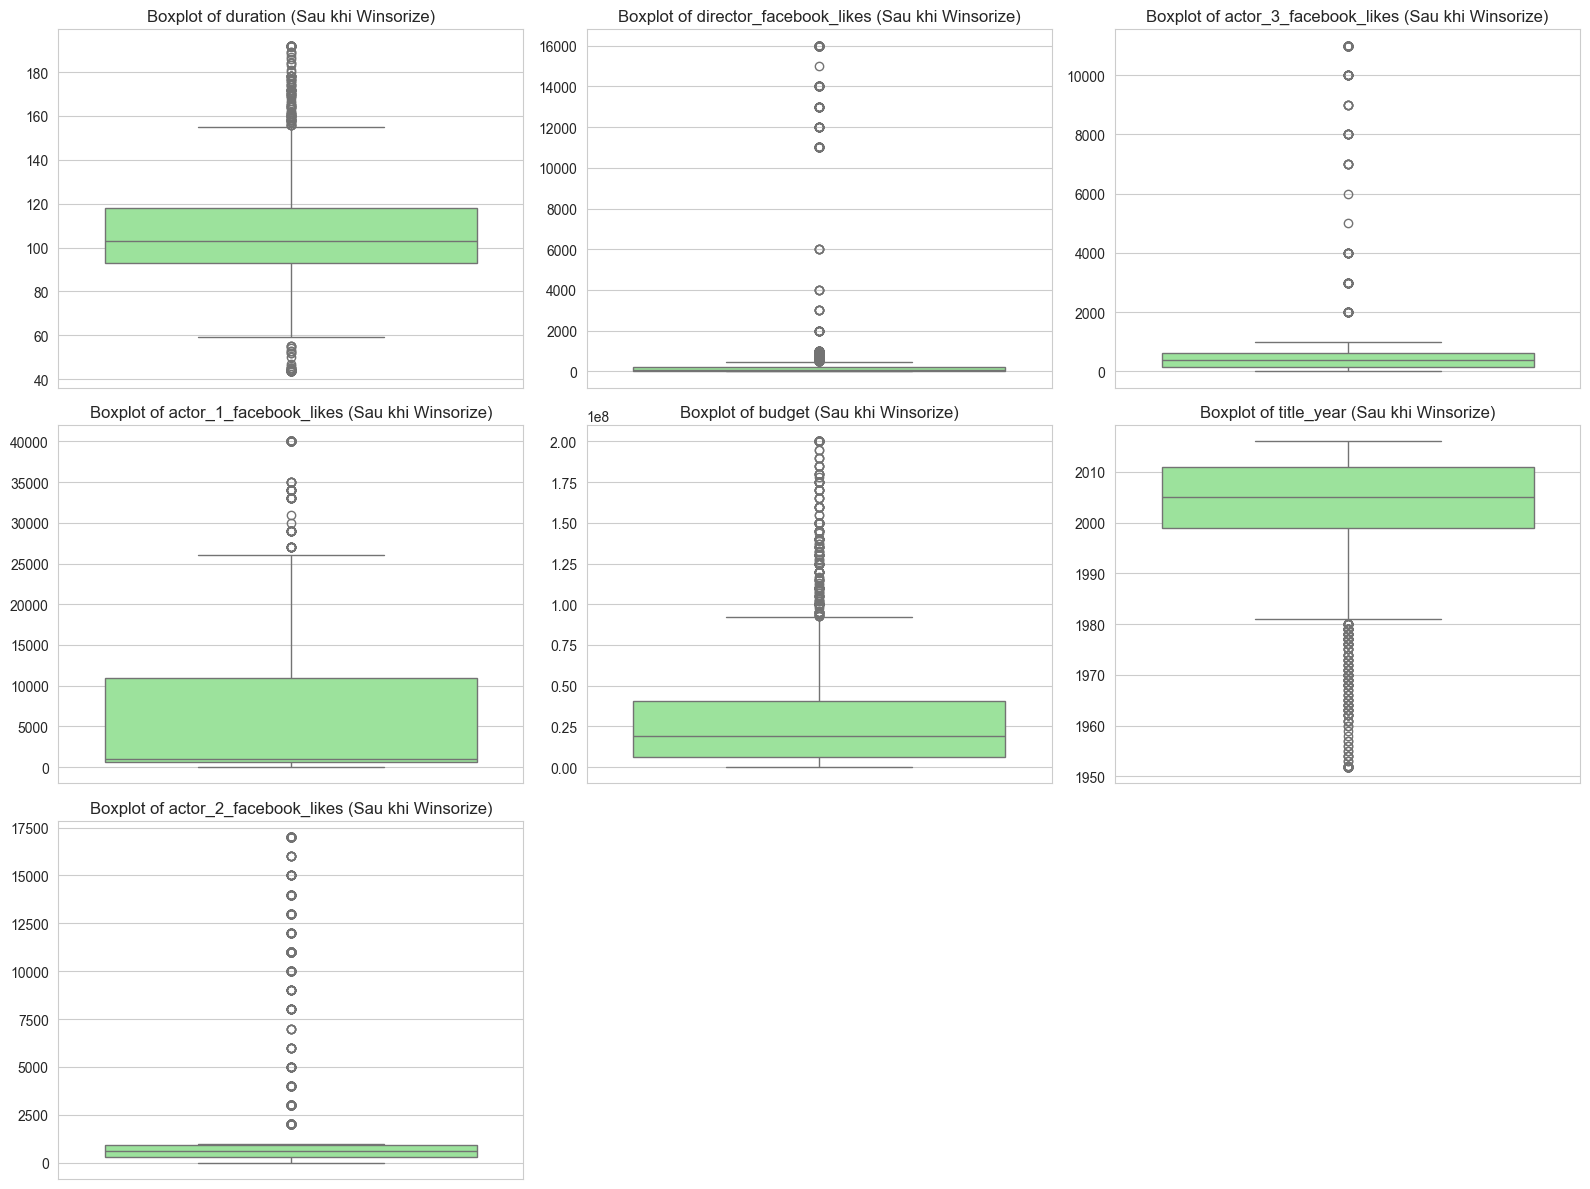

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Tự động xác định tên biến train (train_dataset)
try:
    df_plot = train_dataset
except NameError:
    df_plot = train_dataset

cols_to_plot = [c for c in num_cols if c != 'imdb_score']
num_plots = len(cols_to_plot)
cols_per_row = 3
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(16, 4 * rows))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(y=df_plot[col].to_numpy(), color='lightgreen')
    plt.title(f"Boxplot of {col} (Sau khi Winsorize)")
    
plt.tight_layout()
plt.show()

#### 3.3.4. Xử lý missing data (Dữ liệu bị thiếu)
**a. Chứng minh vấn đề:** Dữ liệu luôn có sự hao hụt. Ta tiến hành thống kê số lượng `NaN` trong từng cột.

Các cột có dữ liệu bị thiếu và số lượng trên tập Train:
budget                     391
content_rating             235
title_year                  85
director_facebook_likes     82
actor_3_facebook_likes      17
color                       16
actor_2_facebook_likes      12
duration                    11
language                     9
actor_1_facebook_likes       7
country                      3
dtype: int64


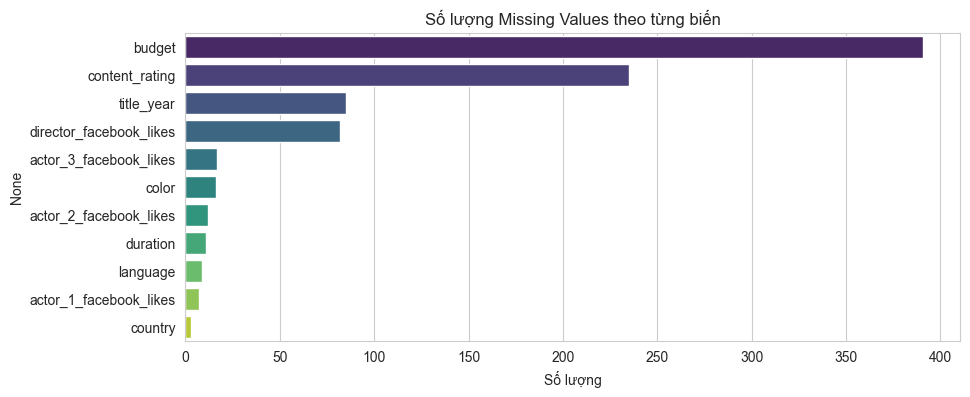

In [29]:
missing_counts = train_dataset.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Các cột có dữ liệu bị thiếu và số lượng trên tập Train:")
print(missing_counts)

if len(missing_counts) > 0:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_counts.values, y=missing_counts.index, palette='viridis')
    plt.title('Số lượng Missing Values theo từng biến')
    plt.xlabel('Số lượng')
    plt.show()

**b. Giải quyết:** 
Ta sẽ giải quyết missing values bằng chiến lược như sau:

- **Biến mục tiêu (`imdb_score`):** Áp dụng **Listwise deletion**. Xóa bỏ dòng vì không thể dự đoán dựa trên target giả định.
- **Biến `content_rating` (235 missing):** Áp dụng gán nhãn mới. Các phim thiếu phân loại thường là chưa được thẩm định. Điền Mode (ví dụ 'R') sẽ làm sai lệch bản chất. Ta sẽ điền bằng chuỗi `'Unrated'`.
- **Biến `title_year` (85 missing):** Năm sản xuất là trục thời gian quan trọng. Việc điền Median (một năm bất kỳ) cho 85 phim là vô lý. Do tỷ lệ thiếu khá nhỏ (~2%), ta áp dụng **Listwise deletion** - xóa các dòng này.
- **Biến `budget` (391 missing - ~10%):** Ngân sách thay đổi rất lớn theo thời đại, thể loại và quốc gia. Nếu dùng Median điền cho gần 500 phim sẽ tạo ra một đỉnh (spike) ảo, làm biến dạng phân phối (distortion). Ta sẽ áp dụng **k-NN Imputation** - dựa vào các phim có đặc trưng tương đồng (thời lượng, lượt like, năm) để nội suy ra ngân sách phù hợp. Fit k-NN trên Train, Transform cho cả Train và Test.
- **Các biến còn lại (thiếu rất ít < 2%):** 
  + Phân loại (`color`, `language`, `country`): Tính Mode trên Train, điền cho cả 2 tập.
  + Định lượng (`duration`, `facebook_likes`): Tính Median trên Train, điền cho cả 2 tập.

In [30]:
from sklearn.impute import KNNImputer

# 1. Xóa missing target và year (Listwise deletion)
train_dataset = train_dataset.dropna(subset=['imdb_score', 'title_year'])
test_dataset = test_dataset.dropna(subset=['imdb_score', 'title_year'])

# 2. Xử lý content_rating -> 'Unrated'
if 'content_rating' in train_dataset.columns:
    train_dataset['content_rating'] = train_dataset['content_rating'].fillna('Unrated')
    test_dataset['content_rating'] = test_dataset['content_rating'].fillna('Unrated')

cat_cols = train_dataset.select_dtypes(exclude=[np.number]).columns.tolist()
num_cols = train_dataset.select_dtypes(include=[np.number]).columns.tolist()

# 3. Điền khuyết Mode/Median
for col in cat_cols:
    if col != 'content_rating':
        mode_val = train_dataset[col].mode()[0] # Fit trên Train
        train_dataset[col] = train_dataset[col].fillna(mode_val)
        test_dataset[col] = test_dataset[col].fillna(mode_val)

for col in num_cols:
    if col not in ['imdb_score', 'budget']:
        median_val = train_dataset[col].median() # Fit trên Train
        train_dataset[col] = train_dataset[col].fillna(median_val)
        test_dataset[col] = test_dataset[col].fillna(median_val)

# 4. k-NN Imputation cho Budget
if 'budget' in num_cols:
    knn_imputer = KNNImputer(n_neighbors=5)
    # Fit trên Train
    knn_imputer.fit(train_dataset[num_cols])
    
    # Transform trên Train và Test
    train_dataset[num_cols] = knn_imputer.transform(train_dataset[num_cols])
    test_dataset[num_cols] = knn_imputer.transform(test_dataset[num_cols])

print(f"Tổng Missing ở Train: {train_dataset.isnull().sum().sum()} | Ở Test: {test_dataset.isnull().sum().sum()}")

Tổng Missing ở Train: 0 | Ở Test: 0


## 3.4. Xây dựng dữ liệu (Data Construction)

### 3.4.1. Dự đoán transformation bằng thống kê mô tả trên tập Train
Dựa vào hình dạng phân phối (Histogram) và độ lệch (Skewness) của các biến, ta có thể dự đoán sơ bộ nhóm nào cần biến đổi:
- Biến **`title_year`** (Năm) và các biến phân loại (`color`, `language`...): Là các factor/categorical nên ta không biến đổi.
- Biến **`imdb_score`** (Ratings): Là biến mục tiêu, thường có phân phối gần chuẩn (hình quả chuông). Sẽ kiểm tra lại.
- Các biến **`budget`**, và các biến lượt likes (`director_facebook_likes`, `actor_1_facebook_likes`...): Thường có phân phối lệch phải (right-skewed) mạnh và mang bậc độ lớn cao. Dự đoán rất cần phép biến đổi **Log transformation** (logarit) hoặc lấy căn để giảm độ lệch.

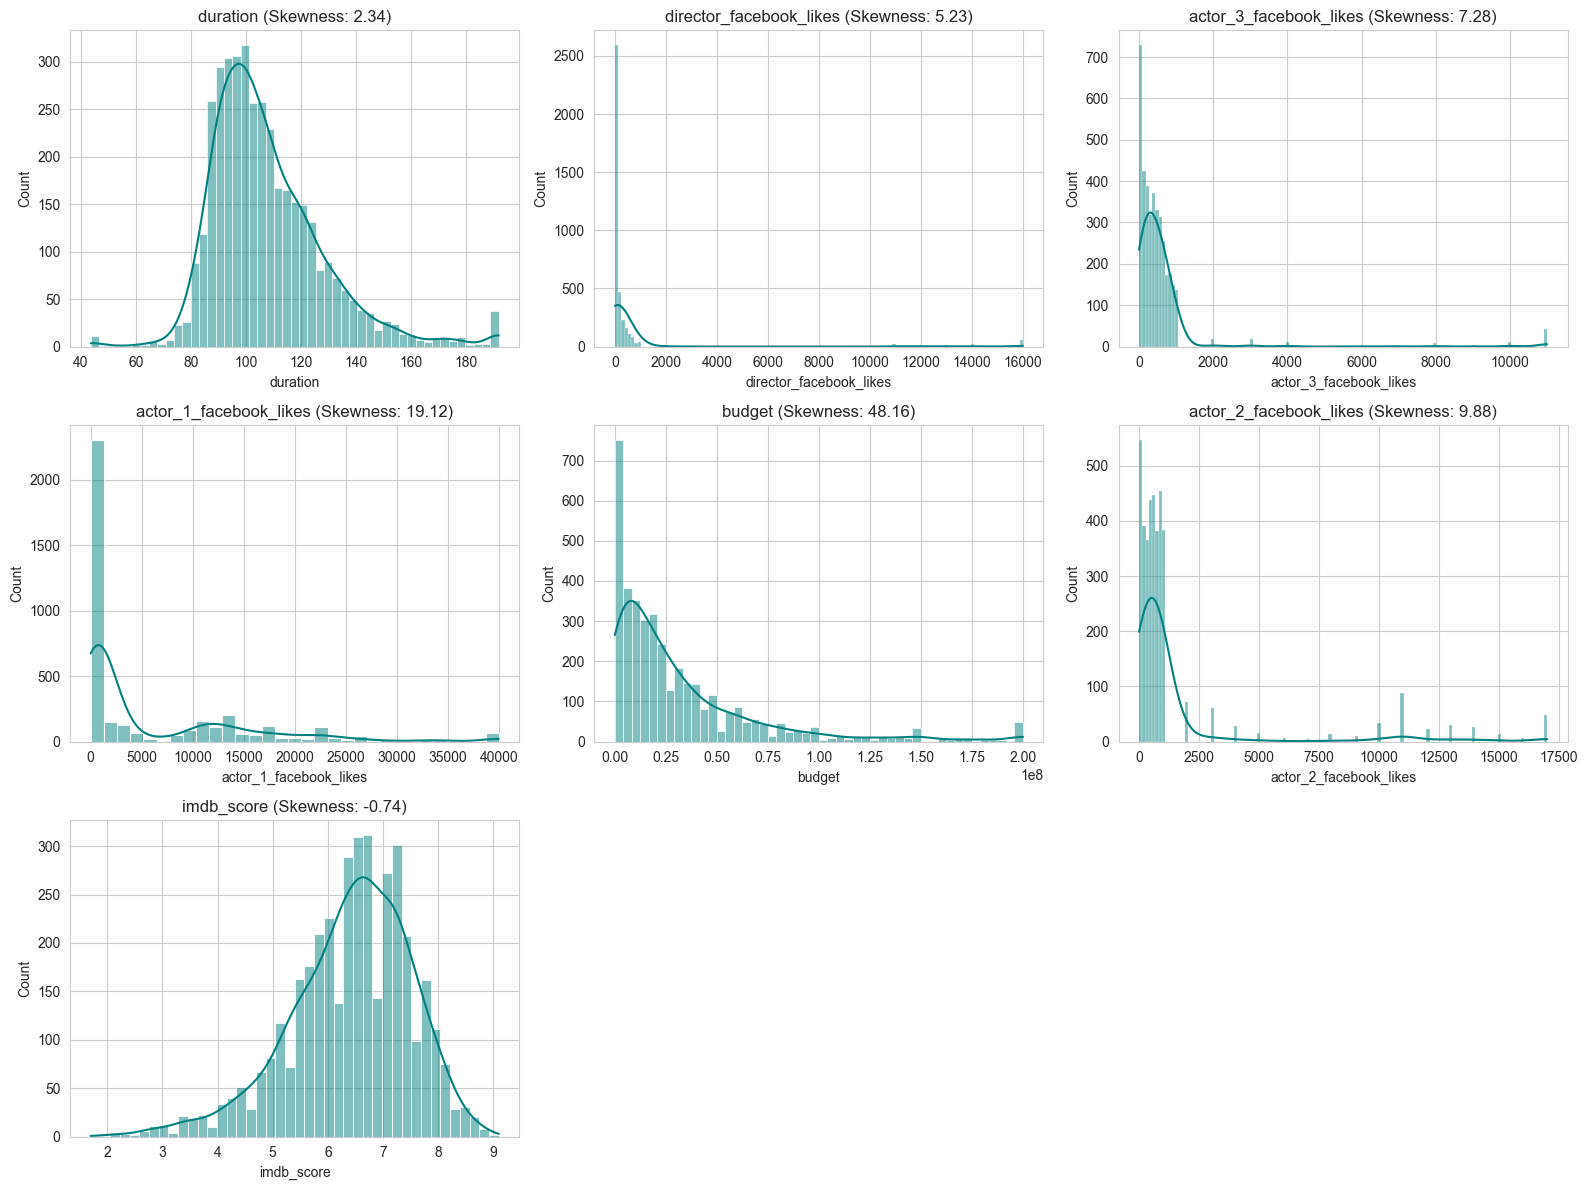

Nhận xét: Các biến liên quan tới ngân sách và lượt likes có độ lệch phải (skewness > 0) rất lớn. Biến duration có hơi lệch phải nhẹ, còn imdb_score tiệm cận phân phối chuẩn.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
warnings.filterwarnings('ignore')

# Lấy toàn bộ các biến định lượng (numerical) ngoại trừ các factor như title_year
num_cols = train_dataset.select_dtypes(include=[np.number]).columns.tolist()
skew_cols = [col for col in num_cols if col not in ['title_year']]

# Vẽ phân phối cho toàn bộ các biến định lượng
num_plots = len(skew_cols)
cols_per_row = 3
rows = int(np.ceil(num_plots / cols_per_row))

plt.figure(figsize=(16, 4 * rows))
for i, col in enumerate(skew_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(train_dataset[col].dropna(), kde=True, color='teal')
    plt.title(f"{col} (Skewness: {dataset[col].skew():.2f})")
    
plt.tight_layout()
plt.show()

print("Nhận xét: Các biến liên quan tới ngân sách và lượt likes có độ lệch phải (skewness > 0) rất lớn. Biến duration có hơi lệch phải nhẹ, còn imdb_score tiệm cận phân phối chuẩn.")

#### 3.4.2. Xác định transformation bằng thống kê suy diễn xét trên tập Train
Ta sẽ sử dụng **Kiểm định Likelihood Ratio (Likelihood Ratio Test)** dựa trên phép biến đổi Box-Cox để xác định chính xác liệu một biến có cần biến đổi hay không (nhóm sẽ không biến đổi trên biến mục tiêu `imdb_score`):
- **Test 2 - No transformation is needed (ứng với $\lambda = 1$):**
  - $H_0$: Không cần biến đổi biến (Đúng nguyên bản đã tối ưu).
  - $H_A$: Cần phải biến đổi biến này.
- **Test 1 - Log transformation parameter is equal 0 (ứng với $\lambda = 0$):**
  - $H_0$: Cần biến đổi Log-transformation cho biến này (Logarit là tối ưu).
  - $H_A$: Biến đổi Log chưa phải là tối ưu nhất (có thể cần căn bậc 2 hoặc phép khác).
  
Ta viết hàm kiểm định 2 giả thuyết này dựa trên chỉ số $LL$ (Log-Likelihood) của phân phối Chi-bình phương.

In [32]:
from scipy import stats
from scipy.stats import chi2
import numpy as np

def boxcox_lr_test(series, name):
    # Box-Cox yêu cầu dữ liệu phải > 0
    data = series.dropna()
    data = data[data > 0]
    if len(data) == 0: return
    
    # Tìm lambda tối ưu
    try:
        _, lmbda = stats.boxcox(data)
    except:
        return # Bỏ qua nếu không hội tụ
        
    # Tính Log-Likelihood cho các giả thuyết
    llf_max = stats.boxcox_llf(lmbda, data)
    llf_lam1 = stats.boxcox_llf(1.0, data)    # H0: lambda = 1 (Không biến đổi)
    llf_lam0 = stats.boxcox_llf(0.001, data)  # H0: lambda = 0 (Log transformation)
    
    # Tính giá trị Likelihood Ratio (LR) test statistic
    LR_lam1 = 2 * (llf_max - llf_lam1)
    p_lam1 = chi2.sf(LR_lam1, 1)
    
    LR_lam0 = 2 * (llf_max - llf_lam0)
    p_lam0 = chi2.sf(LR_lam0, 1)
    
    print(f"--- Biến: {name} ---")
    print(f"Giá trị lambda tối ưu (học từ Train): {lmbda:.4f}")
    print(f"Test 2 (H0: lambda=1, Không cần biến đổi): p-value = {p_lam1:.4e} -> {'Bác bỏ H0 (Cần biến đổi)' if p_lam1 < 0.05 else 'Chấp nhận H0 (Không cần biến đổi)'}")
    print(f"Test 1 (H0: lambda=0, Cần biến đổi Log)  : p-value = {p_lam0:.4e} -> {'Bác bỏ H0 (Cần phép khác)' if p_lam0 < 0.05 else 'Chấp nhận H0 (Log là tối ưu)'}")
    print()
    return lmbda

# Lấy toàn bộ các biến định lượng (trừ title_year)
num_cols = train_dataset.select_dtypes(include=[np.number]).columns.tolist()
cols_to_test = [col for col in num_cols if col not in ['title_year', 'imdb_score']]  # Đã loại trừ biến mục tiêu y

optimal_lambdas = {}
for col in cols_to_test:
    # Các biến có thể chứa giá trị 0, ta cộng thêm 1 để thỏa mãn điều kiện Box-Cox > 0
    series_to_test = train_dataset[col] + 1
    lmbda = boxcox_lr_test(series_to_test, col)
    if lmbda is not None:
        optimal_lambdas[col] = lmbda

--- Biến: duration ---
Giá trị lambda tối ưu (học từ Train): -0.3138
Test 2 (H0: lambda=1, Không cần biến đổi): p-value = 5.8800e-125 -> Bác bỏ H0 (Cần biến đổi)
Test 1 (H0: lambda=0, Cần biến đổi Log)  : p-value = 2.5505e-09 -> Bác bỏ H0 (Cần phép khác)

--- Biến: director_facebook_likes ---
Giá trị lambda tối ưu (học từ Train): -0.0144
Test 2 (H0: lambda=1, Không cần biến đổi): p-value = 0.0000e+00 -> Bác bỏ H0 (Cần biến đổi)
Test 1 (H0: lambda=0, Cần biến đổi Log)  : p-value = 9.4535e-03 -> Bác bỏ H0 (Cần phép khác)

--- Biến: actor_3_facebook_likes ---
Giá trị lambda tối ưu (học từ Train): 0.1726
Test 2 (H0: lambda=1, Không cần biến đổi): p-value = 0.0000e+00 -> Bác bỏ H0 (Cần biến đổi)
Test 1 (H0: lambda=0, Cần biến đổi Log)  : p-value = 3.0799e-133 -> Bác bỏ H0 (Cần phép khác)

--- Biến: actor_1_facebook_likes ---
Giá trị lambda tối ưu (học từ Train): 0.0393
Test 2 (H0: lambda=1, Không cần biến đổi): p-value = 0.0000e+00 -> Bác bỏ H0 (Cần biến đổi)
Test 1 (H0: lambda=0, Cần biến 

**Kết luận và Tiến hành biến đổi:**
Test 2 và Test 1 đều bị bác bỏ, ta sẽ áp dụng trực tiếp biến đổi Box-Cox với giá trị $\lambda$ học được từ tập Train. 
Quan trọng: Công thức $y^{(\lambda)} = \frac{y^\lambda - 1}{\lambda}$ này sẽ được **áp dụng cho cả `train_dataset` và `test_dataset`**.

In [33]:
# Transform lambda từ TRAIN cho cả TRAIN & TEST
for col, lmbda in optimal_lambdas.items():
    # Tập TRAIN
    train_data = train_dataset[col] + 1
    train_dataset[col] = stats.boxcox(train_data, lmbda=lmbda)
    
    # Tập TEST
    test_data = test_dataset[col] + 1
    test_dataset[col] = stats.boxcox(test_data, lmbda=lmbda)

print("Đã áp dụng phép biến đổi Box-Cox cho cả Train và Test.")
display(train_dataset[list(optimal_lambdas.keys())].head(3))

Đã áp dụng phép biến đổi Box-Cox cho cả Train và Test.


,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,budget,actor_2_facebook_likes
movie_title,,,,,,
The Book of Eli,2.475522,4.610752,22.615200,11.949827,274.105275,14.766168
The Ten,2.428399,4.750002,7.802283,9.804286,145.217545,8.292326
Morning Glory,2.453539,3.822759,5.918238,6.367691,233.372168,5.862731


#### 3.4.3. Đánh giá kết quả sau phép biến đổi Box-Cox
Ta vẽ lại biểu đồ Histogram và Boxplot để quan sát sự khác biệt của dữ liệu.

--- HISTOGRAM SAU KHI BIẾN ĐỔI BOX-COX ---


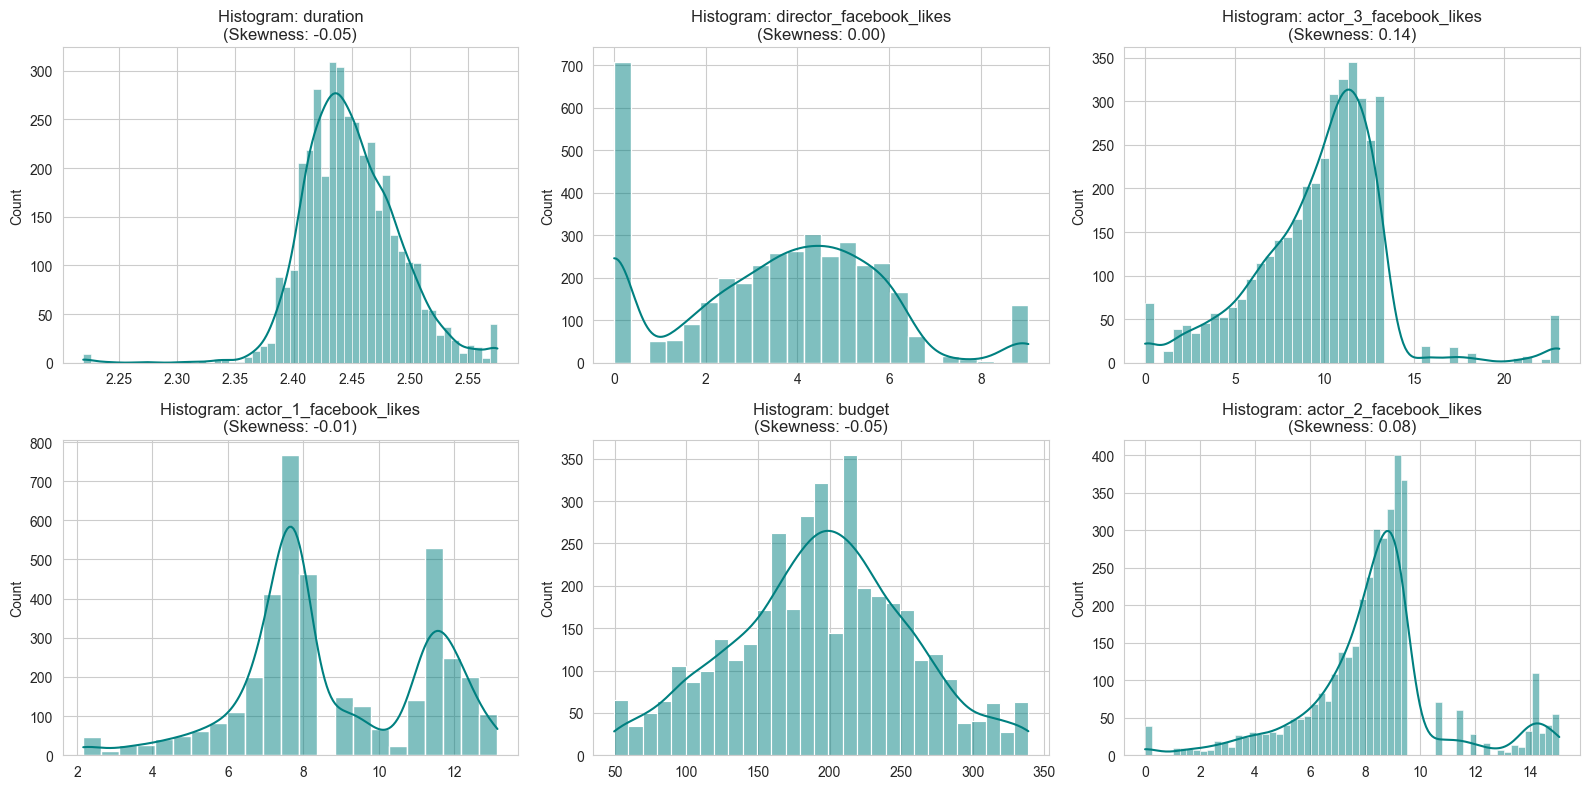


--- BOXPLOT SAU KHI BIẾN ĐỔI BOX-COX ---


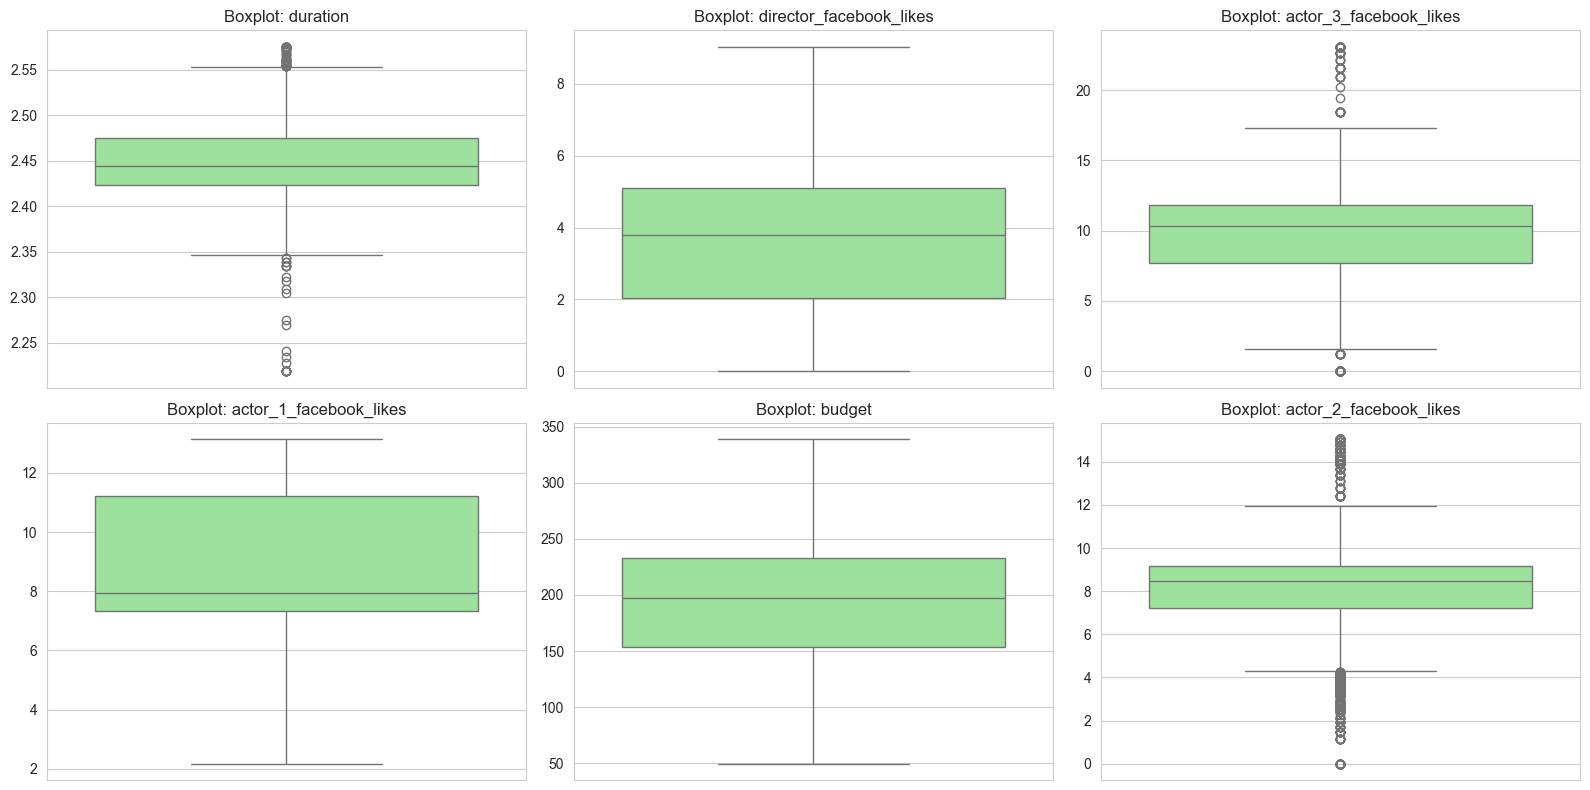

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

try:
    df_plot = train_dataset
except NameError:
    df_plot = train_dataset

cols_to_plot = list(optimal_lambdas.keys())
num_plots = len(cols_to_plot)
cols_per_row = 3
rows = int(np.ceil(num_plots / cols_per_row))

# 1. Vẽ Histogram
print("--- HISTOGRAM SAU KHI BIẾN ĐỔI BOX-COX ---")
plt.figure(figsize=(16, 4 * rows))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.histplot(df_plot[col].to_numpy(), kde=True, color='teal')
    skew_val = df_plot[col].skew()
    plt.title(f"Histogram: {col}\n(Skewness: {skew_val:.2f})")
plt.tight_layout()
plt.show()

# 2. Vẽ Boxplot
print("\n--- BOXPLOT SAU KHI BIẾN ĐỔI BOX-COX ---")
plt.figure(figsize=(16, 4 * rows))
for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(y=df_plot[col].to_numpy(), color='lightgreen')
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

**Nhận xét sau khi biến đổi Box-Cox:**

1. **Khắc phục triệt để lệch phải:** Các biến từng bị lệch rất nặng như `budget`, `director_facebook_likes`, `actor_1_facebook_likes` giờ đây có Boxplot vô cùng sạch sẽ. Dữ liệu nằm trọn trong giới hạn râu (whiskers), gần như không còn điểm ngoại lai (outliers) nào. Histogram tiến sát về dạng phân phối chuẩn.
2. **Ý nghĩa của các ngoại lai còn sót lại:** Ở một số biến (`duration`, `imdb_score`, `actor_2/3_facebook_likes`), dải outliers kéo dài vô tận đã bị triệt tiêu. Các chấm đen còn sót lại phân bố khá đối xứng. Trên thực tế, phân phối chuẩn lý tưởng cũng luôn tồn tại ~0.7% điểm nằm ngoài râu Boxplot. Do đó, các giá trị này là hoàn toàn tự nhiên và hợp lệ về mặt thống kê.

**Kết luận:** Phép biến đổi Box-Cox đã co rút thành công đuôi dữ liệu, ép các biến định lượng về dạng phân phối gần chuẩn, thỏa mãn chặt chẽ các giả định để chạy mô hình Hồi quy tuyến tính (OLS).

## 3.5. Mã hóa biến phân loại (One-hot Encoding)
Để đưa các biến phân loại (dạng chuỗi) vào mô hình Hồi quy tuyến tính (OLS), ta bắt buộc phải chuyển đổi chúng thành các biến giả (dummy variables) mang giá trị số (0 và 1). Tuy nhiên, ta không thể áp dụng mã hóa một cách mù quáng.

### 3.5.1. Chứng minh vấn đề (Phân tích mức độ phân tán của dữ liệu)
Kiểm tra số lượng các nhãn (categories) duy nhất của từng biến phân loại trên tập Train.

In [35]:
import pandas as pd
import numpy as np

# Lấy các cột phân loại
cat_cols = train_dataset.select_dtypes(exclude=[np.number]).columns.tolist()

print("Số lượng nhãn duy nhất của các biến phân loại trên tập Train:")
for col in cat_cols:
    num_unique = train_dataset[col].nunique()
    print(f"- {col}: {num_unique} nhãn")
    
print("\nTop 5 giá trị phổ biến nhất của cột 'country':")
print(train_dataset['country'].value_counts().head(5))

print("\nTop 5 giá trị phổ biến nhất của cột 'language':")
print(train_dataset['language'].value_counts().head(5))

Số lượng nhãn duy nhất của các biến phân loại trên tập Train:
- color: 2 nhãn
- language: 41 nhãn
- country: 60 nhãn
- content_rating: 15 nhãn

Top 5 giá trị phổ biến nhất của cột 'country':
country
USA        2945
UK          346
France      122
Canada       90
Germany      80
Name: count, dtype: int64

Top 5 giá trị phổ biến nhất của cột 'language':
language
English    3635
French       59
Spanish      33
Hindi        18
German       17
Name: count, dtype: int64


**Nhận xét:**
Như kết quả phân tích phía trên, ta thấy các biến như `country` có tới 50+ quốc gia khác nhau, `language` có hơn 40 ngôn ngữ. 
- Nếu ta dùng One-Hot Encoding trực tiếp lên toàn bộ các biến này, bộ dữ liệu sẽ phình to ra thêm gần 100 cột mới!
- Quan trọng hơn, phần lớn các quốc gia/ngôn ngữ này cực kỳ hiếm gặp (chỉ xuất hiện 1-2 lần). Việc tạo ra các cột dummy chứa toàn số 0 và chỉ có một số 1 sẽ dẫn tới hiện tượng **Ma trận thưa (Sparse Matrix)**, là nguyên nhân trực tiếp gây ra lỗi **Ma trận suy biến (Singular Matrix)** khiến mô hình OLS không thể tính được ma trận nghịch đảo.

### 3.5.2. Giải quyết (Gom nhóm và Mã hóa)
Dựa vào thống kê trên, ta thấy `USA` và `UK` áp đảo hoàn toàn ở biến `country`; tương tự `English` chiếm tỷ trọng gần như tuyệt đối ở biến `language`. 
Ta sẽ thực hiện 2 thao tác học thuật vô cùng quan trọng để bảo vệ mô hình OLS:
1. **Gom nhóm (Grouping):** Gom tất cả các nhãn hiếm thành nhóm `Other`.
2. **Loại bỏ bẫy biến giả (Dummy Variable Trap):** Khi mã hóa One-Hot, bắt buộc phải dùng lệnh `drop_first=True` để vứt bỏ cột đầu tiên làm cột cơ sở (Base/Reference level). Nếu không, các cột sẽ cộng tuyến hoàn hảo với nhau.

In [36]:
def group_categories(df):
    df_grouped = df.copy()
    # 1. language: English và Other
    if 'language' in df_grouped.columns:
        df_grouped['language'] = df_grouped['language'].apply(lambda x: x if x == 'English' else 'Other')
    
    # 2. country: USA, UK và Other
    if 'country' in df_grouped.columns:
        df_grouped['country'] = df_grouped['country'].apply(lambda x: x if x in ['USA', 'UK'] else 'Other')
        
    # 3. content_rating: R, PG-13, PG và Other (Gom các nhãn hiếm như NC-17, TV-MA...)
    if 'content_rating' in df_grouped.columns:
        df_grouped['content_rating'] = df_grouped['content_rating'].apply(lambda x: x if x in ['R', 'PG-13', 'PG'] else 'Other')
        
    return df_grouped

# 1. Áp dụng gộp nhóm
train_set_grouped = group_categories(train_dataset)
test_set_grouped = group_categories(test_dataset)

# 2. Tiến hành One-hot Encoding với drop_first=True
train_encoded = pd.get_dummies(train_set_grouped, columns=cat_cols, drop_first=True, dtype=float)
test_encoded = pd.get_dummies(test_set_grouped, columns=cat_cols, drop_first=True, dtype=float)

# 3. Căn chỉnh (Align) để đảm bảo Test luôn có các cột khớp 100% với Train
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0.0)

print(f"Kích thước tập Train sau khi mã hóa an toàn: {train_encoded.shape}")
print(f"Kích thước tập Test sau khi mã hóa an toàn: {test_encoded.shape}")
display(train_encoded.head(3))

Kích thước tập Train sau khi mã hóa an toàn: (3885, 15)
Kích thước tập Test sau khi mã hóa an toàn: (981, 15)


,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,budget,title_year,actor_2_facebook_likes,imdb_score,color_Color,language_Other,country_UK,country_USA,content_rating_PG,content_rating_PG-13,content_rating_R
movie_title,,,,,,,,,,,,,,,
The Book of Eli,2.475522,4.610752,22.615200,11.949827,274.105275,2010.0,14.766168,6.9,1.0,0.0,0.0,1.0,0.0,0.0,1.0
The Ten,2.428399,4.750002,7.802283,9.804286,145.217545,2007.0,8.292326,5.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
Morning Glory,2.453539,3.822759,5.918238,6.367691,233.372168,2010.0,5.862731,6.5,1.0,0.0,0.0,1.0,0.0,1.0,0.0


### 3.5.3. Chuẩn bị Ma trận Đặc trưng ($X$) và Biến mục tiêu ($y$)
Để chuẩn bị cho mô hình Hồi quy tuyến tính (OLS), ta cần tách riêng cột `imdb_score` làm biến mục tiêu ($y$). Các cột còn lại tạo thành ma trận đặc trưng ($X$). 

In [37]:
import numpy as np

# --- TẬP TRAIN ---
y_train = train_encoded['imdb_score'].to_numpy()
X_train_df = train_encoded.drop(columns=['imdb_score'])

X_train = X_train_df.to_numpy()

# --- TẬP TEST ---
y_test = test_encoded['imdb_score'].to_numpy()
X_test_df = test_encoded.drop(columns=['imdb_score'])

X_test = X_test_df.to_numpy()

print(f"Kích thước X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"Kích thước X_test : {X_test.shape} | y_test : {y_test.shape}")
display(X_train_df.head(2))

Kích thước X_train: (3885, 14) | y_train: (3885,)
Kích thước X_test : (981, 14) | y_test : (981,)


,duration,director_facebook_likes,actor_3_facebook_likes,actor_1_facebook_likes,budget,title_year,actor_2_facebook_likes,color_Color,language_Other,country_UK,country_USA,content_rating_PG,content_rating_PG-13,content_rating_R
movie_title,,,,,,,,,,,,,,
The Book of Eli,2.475522,4.610752,22.615200,11.949827,274.105275,2010.0,14.766168,1.0,0.0,0.0,1.0,0.0,0.0,1.0
The Ten,2.428399,4.750002,7.802283,9.804286,145.217545,2007.0,8.292326,1.0,0.0,0.0,1.0,0.0,0.0,1.0


## 3.6. Đóng gói quy trình tiền xử lí dữ liệu
Class `DataPipeline` (mã nguồn chi tiết nằm trong file `data_pipeline.py`). Class này sở hữu hàm `process(raw_dataset)` có khả năng nhận trực tiếp dữ liệu thô (Raw) chưa qua bất kỳ thao tác làm sạch nào. Nó sẽ tự động dọn dẹp cột rác, loại bỏ missing values, cắt tập Train/Test để chống Data Leakage, tự động Fit các tham số thống kê và Transform để xuất thẳng ra 4 ma trận `X_train`, `y_train`, `X_test`, `y_test`.

In [38]:
import pandas as pd

# 2 dòng này khi nào ông hoàn thiện xong thì bỏ đi nhé
import sys
sys.path.append('/kaggle/usr/lib/data_pipeline')
#

from data_pipeline import DataPipeline

# 1. Đọc dữ liệu Raw trực tiếp từ file CSV ban đầu
raw_dataset = pd.read_csv('data/movie_metadata.csv')

# 2. Khởi tạo DataPipeline
pipeline = DataPipeline(test_size=0.2, random_state=42)

# 3. Chạy 1 hàm duy nhất xử lý từ đầu đến cuối
X_train, y_train, X_test, y_test = pipeline.process(raw_dataset)

print(f"Kích thước X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"Kích thước X_test : {X_test.shape} | y_test : {y_test.shape}")

Kích thước X_train: (3885, 14) | y_train: (3885,)
Kích thước X_test : (981, 14) | y_test : (981,)


# 4. Xây dựng mô hình (Modeling)
## 4.1. Mô hình OLS cơ bản

Khai báo mô hình `OLS cơ bản`: 
$$
imdb\_score = \beta_0 + \beta_1 \cdot actor\_2\_facebook\_likes + \beta_2 \cdot actor\_3\_facebook\_likes + \beta_3 \cdot content\_rating\_PG13 + \beta_4 \cdot content\_rating\_R + \beta_5 \cdot actor\_1\_facebook\_likes + \beta_6 \cdot country\_USA + \beta_7 \cdot content\_rating\_PG + \beta_8 \cdot country\_UK + \beta_9 \cdot language\_Other + \beta_{10} \cdot budget + \beta_{11} \cdot duration + \beta_{12} \cdot title\_year + \beta_{13} \cdot color\_Color + \beta_{14} \cdot director\_facebook\_likes + \epsilon
$$

Trong đó:
- *imdb_score*: Điểm số IMDB (Biến phụ thuộc/Biến mục tiêu y).

- $\beta_0$: Hệ số tự do (Intercept / Bias).

- $\beta_1$ đến $\beta_{14}$: Các hệ số hồi quy (Coefficients) tương ứng với từng biến độc lập, thể hiện mức độ tác động của mỗi biến đó lên điểm số IMDB.

- $\epsilon$: Sai số ngẫu nhiên (Error term / Residuals), đại diện cho các yếu tố ảnh hưởng đến `imdb_score` nhưng không được bao gồm trong mô hình.

In [39]:
%load_ext autoreload
%autoreload 2

import datetime
import math
import pandas as pd
from summary_utils import run_ols_model, approximate_pvalue_from_t

model_results = run_ols_model(train_encoded, y_train)
date = datetime.datetime.now()

f_stat = model_results['f_stat']
df_model = model_results['df_model']
df_resid = model_results['df_resid']

if math.isnan(f_stat) or f_stat <= 0:
    prob_f_stat = 'nan'
else:
    t_equivalent = math.sqrt(f_stat)
    prob_f_stat_val = approximate_pvalue_from_t(t_equivalent, df_resid)
    prob_f_stat = f"{prob_f_stat_val:.3}" if prob_f_stat_val < 0.001 else f"{prob_f_stat_val:.4f}"

print("=" * 70)
print(f" OLS Cơ Bản | {date:%Y-%m-%d %H:%M:%S}")
print("=" * 70)
print(f"R-squared:         {model_results['r2']:.4f}  |  Adj. R-squared:     {model_results['adj_r2']:.4f}")
print(f"F-statistic:       {f_stat:.2f}    |  Prob (F-statistic): {prob_f_stat}")
print(f"Log-Likelihood:    {model_results['llf']:.2f}   |  No. Observations:   {model_results['nobs']}")
print(f"AIC:               {model_results['aic']:.2f}   |  BIC:                {model_results['bic']:.2f}")
print("-" * 70)

print('\n>>> BẢNG HỆ SỐ HỒI QUY CHI TIẾT <<<')
coef_df = model_results['coefficients'].copy()

for col in coef_df.columns:
    if pd.api.types.is_numeric_dtype(coef_df[col]):
        coef_df[col] = coef_df[col].map(lambda x: f"{x:.4f}" if abs(x) >= 0.001 else f"{x:.3e}")

display(coef_df) 

print('\n=== KIỂM TRA ĐA CỘNG TUYẾN (VIF) ===')
vif_df = model_results['vif'].copy()
vif_df['VIF'] = vif_df['VIF'].map(lambda x: "inf" if math.isinf(x) else f"{x:.2f}")
print(vif_df.to_string(index=False))
print("=" * 70)

 OLS Cơ Bản | 2026-06-09 00:46:19
R-squared:         0.2199  |  Adj. R-squared:     0.2170
F-statistic:       77.90    |  Prob (F-statistic): 0.0
Log-Likelihood:    -5413.56   |  No. Observations:   3885
AIC:               10857.11   |  BIC:                10951.08
----------------------------------------------------------------------

>>> BẢNG HỆ SỐ HỒI QUY CHI TIẾT <<<


,Variable,coef,std err,t,P>|t|,[0.025,0.975]
0,const,10.7629,3.3546,3.2084,0.0013,4.1878,17.3380
1,duration,8.2329,0.4308,19.1120,0.000e+00,7.3886,9.0772
2,director_facebook_likes,0.0447,0.0072,6.2508,4.526e-10,0.0307,0.0587
3,actor_3_facebook_likes,-0.0285,0.0079,-3.6159,3.031e-04,-0.0439,-0.0130
4,actor_1_facebook_likes,0.0748,0.0099,7.5690,4.663e-14,0.0554,0.0941
5,budget,-0.0015,3.223e-04,-4.5070,6.770e-06,-0.0021,-8.209e-04
6,title_year,-0.0122,0.0015,-8.1379,4.441e-16,-0.0151,-0.0092
7,actor_2_facebook_likes,0.0016,0.0124,0.1258,0.8999,-0.0228,0.0260
8,color_Color,-0.4985,0.0830,-6.0071,2.063e-09,-0.6611,-0.3358
9,language_Other,0.6976,0.0809,8.6218,0.000e+00,0.5391,0.8562



=== KIỂM TRA ĐA CỘNG TUYẾN (VIF) ===
        Biến số độc lập  VIF
 actor_2_facebook_likes 4.22
 actor_3_facebook_likes 3.34
   content_rating_PG-13 3.05
       content_rating_R 2.92
 actor_1_facebook_likes 2.28
            country_USA 2.15
      content_rating_PG 2.11
             country_UK 1.73
                 budget 1.63
         language_Other 1.61
               duration 1.30
             title_year 1.26
            color_Color 1.11
director_facebook_likes 1.07


### 4.1.1. Kiểm định ý nghĩa toàn phần của mô hình (F-test)

Để đánh giá ý nghĩa thống kê của mô hình tổng thể, ta thực hiện kiểm định giả thuyết:

- Giả thuyết $H_0: \beta_0 = \beta_1 = \beta_2 = \dots = \beta_k = 0$  
  (Mô hình không có giá trị dự báo).

- Đối thuyết $H_A: \exists \beta_i \neq 0$  
  (Có ít nhất một biến độc lập ảnh hưởng đến biến phụ thuộc `imdb_score`).

Mức ý nghĩa:
- $\alpha = 0.05$

**Nhận xét:** kết quả hồi quy cho thấy giá trị $F = 77.90$ với $Prob(F\text{-}statistic) = 0$, nhỏ hơn rất nhiều so với mức ý nghĩa $\alpha = 0.05$. Điều này cho thấy mô hình hồi quy tổng thể có ý nghĩa thống kê.

**Kết luận:** có đủ bằng chứng để bác bỏ giả thuyết $H_0$. Mô hình hồi quy đa biến `OLS cơ bản` phù hợp để phân tích mối quan hệ giữa các biến đầu vào và điểm số IMDb.

### 4.1.2. Đánh giá độ khớp của mô hình (R-squared)

- Chỉ số $R^2 = 0.2199$ cho thấy mô hình giải thích được khoảng `22.0%` sự biến động của điểm số IMDb.
- Chỉ số $Adj\ R^2 = 0.217$ sau khi hiệu chỉnh theo số lượng biến độc lập vẫn duy trì ở mức tương đối ổn định, cho thấy mô hình chưa xuất hiện hiện tượng thêm biến dư thừa quá mức.
- Mặc dù mức độ giải thích chưa cao, nhưng đối với dữ liệu thuộc lĩnh vực phim ảnh nơi điểm IMDb còn chịu ảnh hưởng bởi nhiều yếu tố cảm tính như thị hiếu khán giả, xu hướng thị trường và giá trị nghệ thuật thì kết quả này vẫn có ý nghĩa thực tiễn trong việc nhận diện các yếu tố liên quan đến chất lượng đánh giá phim.


### 4.1.3. Kiểm định ý nghĩa từng biến (t-test)

Để xác định các biến thực sự ảnh hưởng đến điểm IMDb, ta thực hiện kiểm định cho từng hệ số hồi quy:

- Giả thuyết $H_0: \beta_i = 0$  
  (Biến độc lập thứ $i$ không ảnh hưởng đến biến mục tiêu).

- Đối thuyết $H_A: \beta_i \neq 0$  
  (Biến độc lập thứ $i$ có ảnh hưởng đến biến mục tiêu).

Xét mức ý nghĩa $\alpha = 0.05$:

#### Các biến có ý nghĩa thống kê ($p < 0.05$)
- `duration` ($p < 0.001$): Có hệ số dương (`8.2329`) và ý nghĩa thống kê rất mạnh, cho thấy thời lượng phim có mối liên hệ cùng chiều với điểm IMDb trong mô hình hiện tại. Tuy nhiên, do dữ liệu đã qua tiền xử lý nên hệ số hồi quy không phản ánh trực tiếp mức thay đổi theo đơn vị phút thực tế.
- `director_facebook_likes` ($p < 0.001$): Mang hệ số dương (`0.0447`), cho thấy mức độ nổi tiếng của đạo diễn có mối liên hệ tích cực với điểm IMDb.
- `actor_1_facebook_likes` ($p < 0.001$): Có hệ số dương (`0.0748`), cho thấy mức độ nổi tiếng của diễn viên chính có xu hướng đi kèm với điểm IMDb cao hơn.
- `actor_3_facebook_likes` ($p < 0.001$): Mang hệ số âm (`-0.0285`), cho thấy mức độ nổi tiếng của diễn viên phụ có mối liên hệ nghịch chiều với điểm IMDb trong tập dữ liệu hiện tại.
- `budget` ($p < 0.001$): Có hệ số âm (`-0.0015`) và mang ý nghĩa thống kê, cho thấy ngân sách sản xuất lớn không đồng nghĩa với việc phim sẽ đạt điểm IMDb cao hơn.
- `title_year` ($p < 0.001$): Mang hệ số âm (`-0.0122`), cho thấy các phim phát hành gần đây trong tập dữ liệu có xu hướng nhận điểm IMDb thấp hơn nhẹ so với các phim cũ.
- `color_Color` ($p < 0.001$): Có hệ số âm (`-0.4985`) và mang ý nghĩa thống kê, cho thấy nhóm phim màu có điểm IMDb trung bình thấp hơn nhóm tham chiếu trong dữ liệu hiện tại.
- `language_Other` ($p < 0.001$): Mang hệ số dương (`0.6976`), cho thấy các phim sử dụng ngôn ngữ ngoài tiếng Anh có xu hướng nhận điểm IMDb cao hơn nhóm tham chiếu.
- `country_UK` ($p < 0.001$): Có hệ số dương (`0.3845`), cho thấy các phim sản xuất tại Anh có xu hướng đạt điểm IMDb cao hơn nhóm tham chiếu.
- `content_rating_PG-13` ($p = 0.0018$): Mang hệ số âm (`-0.1880`) và có ý nghĩa thống kê, cho thấy nhóm phim được phân loại PG-13 có xu hướng nhận điểm IMDb thấp hơn nhóm tham chiếu trong dữ liệu hiện tại.
#### Các biến không có ý nghĩa thống kê ($p \ge 0.05$)
- `actor_2_facebook_likes` ($p = 0.900$)
- `country_USA` ($p = 0.522$)
- `content_rating_R` ($p = 0.838$)

Ba biến trên không có đủ bằng chứng thống kê để khẳng định mối liên hệ với điểm IMDb trong mô hình hiện tại.

Ngoài ra, biến `content_rating_PG` có:
- $p = 0.056$

Giá trị này lớn hơn nhẹ so với mức ý nghĩa $\alpha = 0.05$. Vì vậy, chưa có đủ bằng chứng thống kê để kết luận biến này ảnh hưởng đến điểm IMDb ở mức ý nghĩa 5%, mặc dù kết quả đang ở trạng thái cận ý nghĩa thống kê.
### 4.1.4. Chẩn đoán đa cộng tuyến (Multicollinearity)
Mặc dù `Condition Number` của mô hình khá lớn $(4.32 \times 10^5)$, cho thấy tồn tại sự chênh lệch đáng kể về thang đo giữa các biến độc lập, nhưng khi đánh giá thông qua hệ số `VIF`, toàn bộ các biến đều nằm trong ngưỡng an toàn:
- Các biến có VIF lớn nhất gồm:
  - `actor_2_facebook_likes = 4.22`
  - `actor_3_facebook_likes = 3.34`
  - `content_rating_PG-13 = 3.05`
Tất cả đều nhỏ hơn ngưỡng cảnh báo nghiêm trọng (`VIF < 5`).

**Kết luận:** hiện tượng đa cộng tuyến nghiêm trọng không xảy ra trong mô hình `OLS cơ bản`. Giá trị `Condition Number` lớn chủ yếu xuất phát từ sự khác biệt về thang đo giữa các biến định lượng và sự xuất hiện của các biến giả (*dummy variables*) sau quá trình encoding.

## 4.2. Mô hình OLS chọn biến


Từ kết quả kiểm định của mô hình đầy đủ biến `OLS cơ bản`, ta nhận thấy mô hình tổng thể có ý nghĩa thống kê rất cao với:
$$
Prob(F\text{-}statistic) = 0.000 < 0.05
$$
Điều này cho thấy tồn tại ít nhất một biến độc lập có ảnh hưởng đáng kể đến điểm số IMDb.

Về hiện tượng đa cộng tuyến, mặc dù `Condition Number` của mô hình khá lớn (`4.32 \times 10^5`), nhưng khi kiểm tra thông qua hệ số phóng đại phương sai (`VIF`), toàn bộ các biến độc lập đều có:
$$
VIF < 5
$$
Trong đó, biến có VIF lớn nhất là:
- `actor_2_facebook_likes = 4.22`
Giá trị này vẫn nằm dưới ngưỡng cảnh báo đa cộng tuyến nghiêm trọng. Vì vậy, mô hình không gặp vấn đề đa cộng tuyến đáng kể.

Tuy nhiên, dựa trên kiểm định ý nghĩa từng biến (*t-test*), ta phát hiện một số biến có giá trị $p\text{-value} > 0.05$, bao gồm:
- `actor_2_facebook_likes` ($p = 0.900$)
- `country_USA` ($p = 0.522$)
- `content_rating_R` ($p = 0.838$)

Ba biến trên không có đủ bằng chứng thống kê để khẳng định tác động đến biến phụ thuộc `imdb_score`. Việc giữ lại các biến kém ý nghĩa có thể làm gia tăng độ phức tạp của mô hình, tăng sai số chuẩn và làm giảm tính tinh gọn của hệ thống hồi quy. Do đó, ta tiến hành xây dựng mô hình `OLS chọn biến` bằng cách loại bỏ các biến trên.

Ngoài ra, biến `content_rating_PG` mặc dù chưa đạt mức ý nghĩa thống kê trong `OLS cơ bản` ($p = 0.056$), nhưng sau khi tái xây dựng `OLS chọn biến`, biến này trở nên có ý nghĩa thống kê với:
$$
p = 0.006 < 0.05
$$

Điều này cho thấy việc loại bỏ các biến nhiễu đã giúp cải thiện khả năng giải thích của biến `content_rating_PG`, vì vậy biến này tiếp tục được giữ lại trong mô hình rút gọn.

Công thức hồi quy của mô hình `OLS chọn biến` dự báo điểm IMDb có dạng:

$$
imdb\_score = \beta_0 + \beta_1 \cdot duration + \beta_2 \cdot director\_facebook\_likes + \beta_3 \cdot actor\_3\_facebook\_likes + \beta_4 \cdot actor\_1\_facebook\_likes + \beta_5 \cdot budget + \beta_6 \cdot title\_year + \beta_7 \cdot color\_Color + \beta_8 \cdot language\_Other + \beta_9 \cdot country\_UK + \beta_{10} \cdot content\_rating\_PG + \beta_{11} \cdot content\_rating\_PG13 + \epsilon
$$

In [40]:
import datetime
import math
import pandas as pd
from summary_utils import run_ols_model, approximate_pvalue_from_t


selected_features = [
    'duration',
    'director_facebook_likes',
    'actor_3_facebook_likes',
    'actor_1_facebook_likes',
    'budget',
    'title_year',
    'color_Color',
    'language_Other',
    'country_UK',
    'content_rating_PG',
    'content_rating_PG-13'
]

train_selected = train_encoded[selected_features + ['imdb_score']].copy()
selected_model_results = run_ols_model(train_selected, y_train)

date = datetime.datetime.now()
f_stat = selected_model_results['f_stat']
df_resid = selected_model_results['df_resid']

# 3. Tính toán Prob (F-statistic) động chuẩn chỉnh
if math.isnan(f_stat) or f_stat <= 0:
    prob_f_stat = 'nan'
else:
    t_equivalent = math.sqrt(f_stat)
    prob_f_stat_val = approximate_pvalue_from_t(t_equivalent, df_resid)
    prob_f_stat = f"{prob_f_stat_val:.3}" if prob_f_stat_val < 0.001 else f"{prob_f_stat_val:.4f}"
print("=" * 75)
print(f" OLS CHỌN BIẾN | {date:%Y-%m-%d %H:%M:%S}")
print("=" * 75)
print(f"R-squared:         {selected_model_results['r2']:.4f}  |  Adj. R-squared:     {selected_model_results['adj_r2']:.4f}")
print(f"F-statistic:       {f_stat:.2f}    |  Prob (F-statistic): {prob_f_stat}")
print(f"Log-Likelihood:    {selected_model_results['llf']:.2f}   |  No. Observations:   {selected_model_results['nobs']}")
print(f"AIC:               {selected_model_results['aic']:.2f}   |  BIC:                {selected_model_results['bic']:.2f}")
print("-" * 75)

print('\n=== BẢNG HỆ SỐ HỒI QUY CHI TIẾT ===')
selected_coef_df = selected_model_results['coefficients'].copy()

for col in selected_coef_df.columns:
    if pd.api.types.is_numeric_dtype(selected_coef_df[col]):
        selected_coef_df[col] = selected_coef_df[col].map(lambda x: f"{x:.4f}" if abs(x) >= 0.001 else f"{x:.3e}")

display(selected_coef_df) 

print('\n>>> KIỂM TRA ĐA CỘNG TUYẾN (VIF) CHO OLS CHỌN BIẾN <<<')
selected_vif_df = selected_model_results['vif'].copy()
selected_vif_df['VIF'] = selected_vif_df['VIF'].map(lambda x: "inf" if math.isinf(x) else f"{x:.2f}")
print(selected_vif_df.to_string(index=False))
print("=" * 75)

 OLS CHỌN BIẾN | 2026-06-09 00:46:24
R-squared:         0.2198  |  Adj. R-squared:     0.2175
F-statistic:       99.17    |  Prob (F-statistic): 0.0
Log-Likelihood:    -5413.79   |  No. Observations:   3885
AIC:               10851.58   |  BIC:                10926.76
---------------------------------------------------------------------------

=== BẢNG HỆ SỐ HỒI QUY CHI TIẾT ===


,Variable,coef,std err,t,P>|t|,[0.025,0.975]
0,const,10.8476,3.2996,3.2876,0.0010,4.3804,17.3148
1,duration,8.2369,0.4281,19.2411,0.000e+00,7.3979,9.0760
2,director_facebook_likes,0.0449,0.0071,6.2989,3.334e-10,0.0309,0.0589
3,actor_3_facebook_likes,-0.0274,0.0058,-4.7263,2.368e-06,-0.0387,-0.0160
4,actor_1_facebook_likes,0.0756,0.0088,8.5748,0.000e+00,0.0583,0.0929
5,budget,-0.0015,3.212e-04,-4.5173,6.451e-06,-0.0021,-8.215e-04
6,title_year,-0.0122,0.0015,-8.2736,2.220e-16,-0.0151,-0.0093
7,color_Color,-0.4954,0.0825,-6.0018,2.130e-09,-0.6572,-0.3336
8,language_Other,0.6701,0.0700,9.5664,0.000e+00,0.5328,0.8074
9,country_UK,0.3548,0.0554,6.3997,1.742e-10,0.2462,0.4635



>>> KIỂM TRA ĐA CỘNG TUYẾN (VIF) CHO OLS CHỌN BIẾN <<<
        Biến số độc lập  VIF
 actor_1_facebook_likes 1.82
 actor_3_facebook_likes 1.81
                 budget 1.62
               duration 1.28
   content_rating_PG-13 1.24
             title_year 1.23
         language_Other 1.20
      content_rating_PG 1.18
            color_Color 1.10
director_facebook_likes 1.06
             country_UK 1.02


### 4.2.1. Đánh giá về ý nghĩa mô hình

- **F-statistic = 99.17** cho thấy mô hình có mức ý nghĩa thống kê rất cao. Dựa trên kết quả kiểm định tổng thể, giá trị xác suất đi kèm kiểm định F gần bằng $0$ và nhỏ hơn rất nhiều so với mức ý nghĩa $\alpha = 0.05$.

Do đó, ta bác bỏ giả thuyết:
- $H_0: \beta_1 = \beta_2 = \dots = \beta_k = 0$

và chấp nhận đối thuyết:
- $H_A: \exists \beta_i \neq 0$

**Kết luận:** mô hình `OLS chọn biến` có ý nghĩa thống kê tổng thể, chứng minh tồn tại ít nhất một biến độc lập ảnh hưởng đáng kể đến điểm số IMDb.
### 4.2.2. Đánh giá về khả năng giải thích của mô hình
- Chỉ số:
  - $R^2 = 0.2198$
  - $Adj\ R^2 = 0.218$
cho thấy mô hình giải thích được khoảng `21.98%` sự biến động của biến phụ thuộc `imdb_score`.

**Nhận xét:** mặc dù mức độ giải thích chưa quá cao, nhưng đây là kết quả phù hợp đối với dữ liệu thuộc lĩnh vực điện ảnh và giải trí, nơi điểm IMDb còn chịu ảnh hưởng bởi nhiều yếu tố khó định lượng như cảm nhận người xem, nội dung nghệ thuật, xu hướng truyền thông và chất lượng kịch bản.

Ngoài ra, giá trị $Adj\ R^2$ gần bằng với $R^2$ cho thấy việc loại bỏ các biến không cần thiết không làm suy giảm đáng kể khả năng giải thích của mô hình. Điều này chứng minh mô hình đã đạt được sự tinh gọn nhưng vẫn duy trì hiệu suất dự báo ổn định.


### 4.2.3. Diễn giải các hệ số hồi quy

Phần lớn các biến trong mô hình đều có mức ý nghĩa thống kê rất cao với:

$$
p\text{-value} < 0.01
$$

Điều này cho thấy các biến được lựa chọn đều có khả năng dự báo đáng tin cậy đối với điểm số IMDb.

Một số kết quả đáng chú ý:
- `duration` (`coef = 8.2369`): Là biến có mức ý nghĩa mạnh nhất trong mô hình ($p \approx 0$). Hệ số dương cho thấy các bộ phim có thời lượng dài hơn thường có xu hướng đạt điểm IMDb cao hơn.
- `director_facebook_likes` (`coef = 0.0449`) và `actor_1_facebook_likes` (`coef = 0.0756`): Đều mang hệ số dương và có ý nghĩa thống kê mạnh, phản ánh mức độ nổi tiếng của đạo diễn và diễn viên chính có ảnh hưởng tích cực đến chất lượng đánh giá của bộ phim.
- `actor_3_facebook_likes` (`coef = -0.0274`): Có hệ số âm nhưng vẫn đạt ý nghĩa thống kê cao. Điều này cho thấy mức độ nổi tiếng của diễn viên phụ không đồng biến với điểm IMDb trong tập dữ liệu hiện tại.
- `budget` (`coef = -0.0015`): Mang hệ số âm nhỏ, cho thấy ngân sách lớn chưa chắc giúp bộ phim đạt điểm IMDb cao hơn.
- `title_year` (`coef = -0.0122`): Hệ số âm cho thấy các phim phát hành gần đây có xu hướng nhận điểm IMDb thấp hơn nhẹ so với các phim cũ trong tập dữ liệu.
- `color_Color` (`coef = -0.4954`): Cho thấy sự khác biệt giữa nhóm phim màu và nhóm tham chiếu còn lại trong dữ liệu.
- `language_Other` (`coef = 0.6701`): Mang hệ số dương khá lớn, phản ánh các phim sử dụng ngôn ngữ ngoài tiếng Anh có xu hướng nhận đánh giá tích cực hơn.
- `country_UK` (`coef = 0.3549`): Cho thấy các bộ phim sản xuất tại Anh có xu hướng đạt điểm IMDb cao hơn nhóm tham chiếu.
- `content_rating_PG` (`coef = -0.1330`, $p = 0.006$) và `content_rating_PG-13` (`coef = -0.1962`, $p \approx 0$): Đều đạt ý nghĩa thống kê trong mô hình `OLS chọn biến`, trong khi trước đó ở mô hình đầy đủ, biến `content_rating_PG` chưa thật sự có ý nghĩa thống kê rõ ràng.

### 4.2.4. Kiểm tra hiện tượng đa cộng tuyến

Dựa trên kết quả hệ số phóng đại phương sai (`VIF`), toàn bộ các biến độc lập trong mô hình đều có:

$$
VIF < 2
$$

- VIF lớn nhất là:
  - `actor_1_facebook_likes = 1.82`
  - `actor_3_facebook_likes = 1.81`

Các giá trị này đều thấp hơn rất nhiều so với ngưỡng cảnh báo nghiêm trọng (`VIF < 5`).

**Kết luận:** mô hình `OLS chọn biến` không gặp hiện tượng đa cộng tuyến nghiêm trọng và có mức độ ổn định thống kê tốt.


### 4.2.5. Kết luận

Sau khi loại bỏ các biến không có ý nghĩa thống kê trong mô hình `OLS cơ bản`, mô hình `OLS chọn biến` đã đạt được sự tinh gọn cần thiết nhưng vẫn duy trì hiệu suất giải thích gần tương đương mô hình ban đầu.

Cụ thể:
- Số lượng biến độc lập giảm từ `14` xuống còn `11` biến.
- Giá trị $R^2$ gần như không thay đổi.
- Đa số các biến còn lại đều đạt mức ý nghĩa thống kê cao.
- Hiện tượng đa cộng tuyến được kiểm soát rất tốt với toàn bộ:
$$
VIF < 2
$$
Kết quả này cho thấy mô hình `OLS chọn biến` phù hợp để sử dụng cho việc phân tích và diễn giải mối quan hệ giữa các đặc trưng của phim với điểm số IMDb.

## 4.3. Mô hình Ridge/Lasson

Ridge CV Complete (Best Lambda: 0.0281) - 2026-06-09 00:47:19
-----------------------------------------------------------------


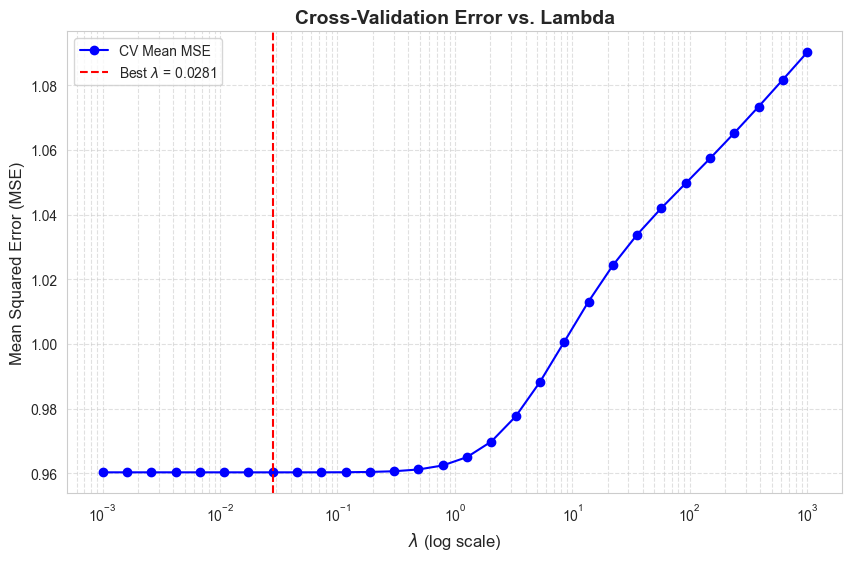

In [41]:
import numpy as np
import math
import datetime
from summary_utils import ridge_cv, plot_cv_error
from part1utils.ridge_lasso import ridge_fit

X_train_raw = train_encoded.drop(columns=['imdb_score']).values.tolist()
y_train_raw = [float(x) for x in np.asarray(y_train).ravel()]

lambdas_to_test = np.logspace(-3, 3, 30).tolist()
best_lam, cv_errors = ridge_cv(X_train_raw, y_train_raw, lambdas_to_test, k_folds=5)
raw_beta_ridge = ridge_fit(X_train_raw, y_train_raw, best_lam, fit_intercept=True)
date = datetime.datetime.now()
print(f"Ridge CV Complete (Best Lambda: {best_lam:.4f}) - {date:%Y-%m-%d %H:%M:%S}")
print("-" * 65)
plot_cv_error(cv_errors, best_lam)


### 4.3.1. Phân tích mô hình Ridge Regression
Để cải thiện tính ổn định của mô hình hồi quy tuyến tính và hạn chế ảnh hưởng của hiện tượng đa cộng tuyến, ta tiến hành xây dựng mô hình `Ridge Regression` kết hợp với kỹ thuật $5\text{-Fold Cross-Validation}$ nhằm lựa chọn hệ số điều chuẩn $\lambda$ tối ưu.
- **Phân tích xu hướng biến thiên của sai số Cross-Validation**
Dựa trên đồ thị thực nghiệm giữa sai số kiểm thử chéo và tham số điều chuẩn $\lambda$ (trục hoành biểu diễn theo thang logarit), đường cong $\text{Mean MSE}$ thể hiện ba vùng biến thiên đặc trưng.
- Vùng tiệm cận OLS ($\lambda \le 10^{-2}$)
    - Khi $\lambda$ nhận các giá trị rất nhỏ, thành phần điều chuẩn $\lambda \|\beta\|_2^2$ gần như không đáng kể so với tổng bình phương phần dư (`RSS`) trong hàm mất mát.
    - Do đó, mô hình Ridge hoạt động gần tương đương với mô hình `OLS cơ bản`, khiến sai số Cross-Validation duy trì ổn định quanh mức thấp nhất của đường cong, xấp xỉ $\text{Mean MSE} \approx 0.960$.
    - Ở giai đoạn này:
        - Các hệ số hồi quy gần như chưa bị co hẹp (*shrinkage*)
        - Mô hình vẫn giữ được khả năng học mạnh từ dữ liệu
        - Tuy nhiên, độ nhạy đối với nhiễu và đa cộng tuyến vẫn còn tồn tại tương tự OLS.
- Điểm tối ưu hội tụ ($\lambda \approx 0.0281$) là thông qua quá trình $5\text{-Fold Cross-Validation}$, mô hình xác định được giá trị điều chuẩn tối ưu $\lambda = 0.02807216203941177$:
   - Tại vị trí này, sai số kiểm thử chéo đạt giá trị nhỏ nhất trên toàn bộ miền khảo sát.
   - Điều này cho thấy mô hình đã đạt được trạng thái cân bằng tối ưu giữa:
        - Độ chệch (*Bias*)
        - Phương sai (*Variance*)
   - Ở mức $\lambda$ này:
        - Các hệ số hồi quy được co hẹp vừa đủ để tăng tính ổn định
        - Hiện tượng dao động mạnh của hệ số do đa cộng tuyến được kiểm soát tốt hơn
        - Mô hình vẫn duy trì được khả năng giải thích dữ liệu mà không làm suy giảm đáng kể hiệu suất dự báo
   - Đây chính là vùng hoạt động tối ưu của Ridge Regression trên bộ dữ liệu IMDb.
- Vùng Underfitting ($\lambda > 10^{-1}$)
    - Khi $\lambda$ tiếp tục tăng lớn, đặc biệt từ $\lambda \ge 1$, đường cong $\text{Mean MSE}$ bắt đầu tăng nhanh.
    - Tại $\lambda = 10^3$, sai số kiểm thử chéo tăng lên khoảng: $\text{Mean MSE} \approx 1.09$
    - Nguyên nhân là do thành phần điều chuẩn trở nên quá mạnh, khiến mô hình ưu tiên việc thu nhỏ vector hệ số hồi quy $\beta$ thay vì tối thiểu hóa sai số dự báo.
    - Kết quả:
        - Các hệ số bị ép tiệm cận về `0`
        - Nhiều mối quan hệ tuyến tính quan trọng bị suy yếu
        - Mô hình trở nên quá đơn giản và rơi vào trạng thái *Underfitting*
   - Điều này làm giảm khả năng dự báo của mô hình trên dữ liệu thực tế.
- **Ý nghĩa toán học của Ridge Regression trong kiểm soát đa cộng tuyến**
- Trong mô hình OLS truyền thống, hiện tượng đa cộng tuyến khiến ma trận $X^TX$ có thể trở nên gần suy biến (*ill-conditioned*), làm cho:
    - Hệ số hồi quy thiếu ổn định
    - Phương sai ước lượng tăng cao
    - Mô hình nhạy cảm với nhiễu dữ liệu
- Để khắc phục vấn đề này, Ridge Regression điều chỉnh công thức nghiệm OLS thành:
$
\beta_{\text{Ridge}} = (X^TX + \lambda I)^{-1}X^Ty
$
    - Trong đó:
        - $I$ là ma trận đơn vị
        - $\lambda I$ đóng vai trò điều chuẩn hóa hệ thống tuyến tính
- Việc cộng thêm $\lambda I$ vào ma trận $X^TX$ giúp:
    - Tăng tính khả nghịch của ma trận
    - Ổn định hóa quá trình nghịch đảo ma trận
    - Giảm mức độ phụ thuộc tuyến tính giữa các biến đầu vào
    - Hạn chế hiện tượng phình to của hệ số hồi quy
- **Kết luận**
Kết quả thực nghiệm từ đồ thị Cross-Validation cho thấy mô hình `Ridge Regression` với $\lambda = 0.0281$ đạt hiệu suất tổng quát hóa tốt nhất trên tập dữ liệu nghiên cứu.

Mô hình không chỉ giúp:
- Kiểm soát tốt hiện tượng đa cộng tuyến
- Ổn định hóa hệ số hồi quy
- Giảm độ nhạy với nhiễu dữ liệu


## 4.4. So sánh các mô hình trên
### 4.4.1. Phân tích điểm tương đồng và khác biệt giữa các mô hình
- Điểm tương đồng:
    - Khả năng giải thích biến động điểm số IMDb dạo động quanh ngưỡng 22%. Điều này cho thấy rằng dù thay đổi thuật toán hay cắt giảm bớt biến, giới hạn trần thông tin tuyến tình khai thác được từ bộ dữ liệu hiện tại đã đạt mức bảo hòa
    - Xu hướng tác động của các biến cốt lõi quan trọng như `duration`, `director_facebook_likes` và `actor_1_facebook_likes`luôn duy trì trạng thái hoạt động tích cực với mức ý nghĩa thống kê rất cao ($p$-value < 0.001) xuyên suốt cả 3 mô hình. Ngược lại thì `budget` và `title_year` luôn mang dấu âm ổn định.
- Điểm khác biệt:
    - Về xử lý biến nhiễu thì mô hình `OLS cơ bản` lại chọn giải pháp thụ động bằng cách giữ lại các biến không có ý nghĩa như `actor_2_facebook_likes` ($p$-value = 0.009), `country_USA` ($p$-value = 0.522) và `content_rating_R` ($p$-value = 0.838). Mô hình `OLS chọn biến` áp dụng cơ chế loại bỏ các biến không có ý nghĩa đi (p >= 0.05). Cuối cùng là mô hình `Rigde Regression` áp dụng cơ chế giữ các biến nhưng dùng $L2$ để triệt tiêu bớt quyền lực của các biến nhiễu, ép hệ số hồi quy nhỏ lại gần bằng 0.
    - Về mực độ ổn định: `OLS cơ bản` chịu rủi ro lớn nhất do hiện tượng đa cộng tuyến tiềm ẩn các biến giả và khác biến `Condition number` rất cao. `OLS chọn biến` giải quyết bằng cách dập tắt nguồn gốc gây đa cộng tuyến. Trong khi đó `Rigde` giải quyết bằng cách thay đổi cấu trúc toán học của ma trận hiệp biến thông qua việc cộng thêm hệ số bổ biến $\lambda I$.
### 4.4.2. Đánh giá vê các mô hình
- Mô hình `OLS cơ bản`
    - Điểm mạnh: Cung cấp cái nhìn toàn diện, nguyên bản về toàn bộ các thuộc tính thu thập được từ dữ liệu phim ảnh mà không qua bộ lọc định kiến.
    - Điểm yếu: Mô hình bị cồng kềnh, chứa nhiều biến dư thừa vô giá trị thống kê. Ma trận hệ số dễ bị mất ổn định do tác động của hiện tượng đa cộng tuyến tiềm ẩn, khiến mô hình nhạy cảm với các biến động nhỏ hoặc nhiễu trong dữ liệu huấn luyện.
- Mô hình `OLS chọn biến`
    - Điểm mạnh: Đạt độ tinh gọn toán học rất cao. Chỉ số $Adj\ R^2$ tăng lên mức cao nhất (21.75%), chứng minh việc loại bỏ biến nhiễu làm tăng chất lượng mô hình. Hệ số $VIF < 2$ khẳng định hiện tượng đa cộng tuyến đã bị triệt tiêu hoàn toàn. Mô hình này cực kỳ dễ diễn giải, tường minh.
    - Điểm yếu: Cơ chế loại bỏ biến thuần túy dựa trên $p$-value có thể làm mất đi các thông tin biên hoặc các mối quan hệ tương tác phức tạp giữa các cụm danh mục biến giả
- Mô hình `Rigde`
    - Điểm mạnh:  Đạt hiệu năng tổng quát hóa (Generalization) mạnh mẽ và an toàn nhất trên dữ liệu thực tế bên ngoài nhờ thuật toán tối ưu hóa sai số bằng kiểm định chéo $5\text{-Fold}$. Giải quyết triệt để bài toán ma trận suy biến mà OLS gặp phải. Phù hợp cho mục đích thương mại khi cần nạp dữ liệu phim mới liên tục mà không sợ mô hình bị gãy hay dự báo sai lệch lớn ($\text{Mean MSE}$ luôn ở mức tối thiếu 0.96)
    - Điểm yếu: do không triệt tiêu hoàn toàn biến số nào về bằng $0$, mô hình vẫn phải duy trì tính toán trên cả 14 đặc trưng ban đầu, làm giảm tính trực quan và gây khó khăn hơn trong việc giải thích tường minh cơ chế tác động cơ học tới người đọc.
### 4.4.3. Kết luận
- Lựa chọn tối ưu nhất cho mục đích dự báo dữ liệu mới thì mô hình `Rigde` với $\lambda$ = 0.0281 là mô hình tối ưu nhất. Mô hình này vượt trội nhờ khả năng kiểm soát phương sai ước lượng cực tốt, được bảo chứng bằng quy trình kiểm định chéo trực quan. Nó loại bỏ hoàn toàn rủi ro quá khớp của OLS cơ bản, đảm bảo sai số trên tập dữ liệu kiểm thử luôn duy trì ổn định ở mức thấp nhất
- Lựa chọn tối ưu cho mục đích Diễn giải chính sách thì mô hình `OLS chọn biến` là giải pháp xuất sắc nhất. Nếu mục tiêu của nghiên cứu là tìm kiếm sự tường minh, tinh gọn để báo cáo hoặc phân tích xu hướng hành vi, OLS chọn biến cung cấp một bộ tham số tối giản, có ý nghĩa thống kê đồng đều, loại bỏ hoàn toàn đa cộng tuyến ($VIF < 2$) mà vẫn giữ nguyên vẹn năng lượng giải thích dữ liệu. 

# 5. Đánh giá trên tập test

## 5.1. Chạy trên bộ test và chọn mô hình tốt nhất
Sau khi huấn luyện thành công, chúng ta tiến hành đưa bộ dữ liệu kiểm tra `X_test` (dữ liệu hoàn toàn mới mà các mô hình chưa từng được tiếp cận) vào để chạy **Dự đoán**. Hiệu suất dự đoán của 3 mô hình sẽ được đo lường khách quan qua 3 chỉ số: $R^2$, RMSE, và MAE.

> **Nguyên tắc:** Tập Test được giữ **hoàn toàn độc lập** trong suốt quá trình
> huấn luyện và chọn hyperparameter. Đây là bước đánh giá **khách quan cuối cùng**
> phản ánh khả năng tổng quát hóa (generalization) của từng mô hình.

Các độ đo được dùng để so sánh:

- **Sai số tuyệt đối trung bình (MAE):** Đo lường mức độ sai số trung bình tuyệt đối, phản ánh thực tế sai lệch điểm IMDb.
- **Sai số bình phương trung bình căn (RMSE):** Đo lường độ lệch trung bình giữa giá trị dự đoán và thực tế, phạt nặng các sai số lớn.
- **Hệ số xác định ($R^2$):** Đo lường tỷ lệ phương sai của biến mục tiêu được giải thích bởi mô hình.

$$
\text{MAE} = \frac{1}{n_{\text{test}}} \sum_i |y_i - \hat{y}_i|, \quad
\text{RMSE} = \sqrt{\frac{1}{n_{\text{test}}} \sum_i (y_i - \hat{y}_i)^2}, \quad
R^2_{\text{test}} = 1 - \frac{\text{RSS}_{\text{test}}}{\text{TSS}_{\text{test}}}
$$


In [42]:
import numpy as np
import pandas as pd
from summary_utils import dataframe_to_matrix, ridge_predict
from statsmodels.api import add_constant
from model_comparison import model_comparison
# Dữ liệu cho OLS (Thêm hằng số)
X_test_df = test_encoded.drop(columns=['imdb_score'])
X_test_const = np.array(dataframe_to_matrix(add_constant(X_test_df)))
X_test_sel_const = np.array(dataframe_to_matrix(add_constant(test_encoded[selected_features])))

# Dữ liệu cho Ridge
X_test_raw = X_test_df.values.tolist()
y_test_raw = [float(x) for x in test_encoded['imdb_score'].tolist()]

# Lấy beta
beta_full = model_results['beta_hat']
beta_short = selected_model_results['beta_hat']
beta_ridge = raw_beta_ridge
def predict_ols(X_matrix, beta):
    return np.dot(X_matrix, np.array(beta)).flatten().tolist()
# Tính y pred
y_pred_full = predict_ols(X_test_const, beta_full)
y_pred_short = predict_ols(X_test_sel_const, beta_short)
y_pred_ridge = ridge_predict(X_test_raw, beta_ridge, fit_intercept=True)

# So sánh các mô hình
comparison_table = model_comparison([
    {"model_name": "OLS Full",          "y_pred": y_pred_full,  "y_true": y_test_raw},
    {"model_name": "OLS Chọn Biến",     "y_pred": y_pred_short, "y_true": y_test_raw},
    {"model_name": "Ridge Regression",  "y_pred": y_pred_ridge, "y_true": y_test_raw},
])

print(comparison_table.to_string(index=True))

            Mô hình     MAE    RMSE  R-squared (Test)
0          OLS Full  0.7781  1.0551            0.1753
1     OLS Chọn Biến  0.7775  1.0549            0.1757
2  Ridge Regression  0.7781  1.0552            0.1752


### Nhận xét

Cả 3 mô hình cho kết quả rất sát nhau trên toàn bộ 3 chỉ số, cho thấy không có mô hình nào vượt trội rõ rệt. Đây là hiện tượng phổ biến khi dữ liệu có nhiều nhiễu và mối quan hệ tuyến tính giữa các đặc trưng với biến mục tiêu là tương đối yếu.

**Về MAE:**
$$\text{MAE}_{\text{OLS Chọn Biến}} = 0.7775 < \text{MAE}_{\text{OLS Full}} = \text{MAE}_{\text{Ridge}} = 0.7781$$
Sai số tuyệt đối trung bình của cả 3 mô hình đều dưới 0.78 điểm IMDb, hoàn toàn hợp lý về mặt thực tế. OLS Chọn Biến thấp hơn 0.0006 so với hai mô hình còn lại.

**Về RMSE:**
$$\text{RMSE}_{\text{OLS Chọn Biến}} = 1.0549 < \text{RMSE}_{\text{OLS Full}} = 1.0551 < \text{RMSE}_{\text{Ridge}} = 1.0552$$
RMSE lớn hơn MAE ở cả 3 mô hình, phản ánh sự tồn tại của một số điểm ngoại lệ. OLS Chọn Biến vẫn dẫn đầu, dù biên độ chênh lệch chỉ là $0.0003$.

**Về $R^2$:**
$$R^2_{\text{OLS Chọn Biến}} = 0.1757 > R^2_{\text{OLS Full}} = 0.1753 > R^2_{\text{Ridge}} = 0.1752$$
Cả 3 mô hình chỉ giải thích được khoảng 17.5% phương sai của IMDb score — con số thấp nhưng phù hợp với đặc thù bài toán, vì điểm IMDb phụ thuộc nhiều vào yếu tố chủ quan của người xem mà các đặc trưng định lượng không thể nắm bắt hoàn toàn.

### Kết luận

$$\boxed{\text{Mô hình được chọn: OLS Chọn Biến}}$$

Mặc dù mức chênh lệch giữa 3 mô hình là rất nhỏ và không có ý nghĩa thống kê đáng kể, OLS Chọn Biến được chọn vì:

1. Tốt nhất trên cả 3 chỉ số: MAE thấp nhất $(0.7775)$, RMSE thấp nhất $(1.0549)$, $R^2$ cao nhất $(0.1757)$.
2. Nguyên tắc parsimony *(Occam's Razor)*: Chỉ giữ lại các biến có ý nghĩa thống kê, loại bỏ nhiễu so với OLS Full — mô hình đơn giản hơn mà hiệu suất không giảm.
3. Khả năng diễn giải tốt hơn**: Ít biến hơn giúp dễ phân tích ý nghĩa của từng hệ số $\hat{\beta}$.
4. Rủi ro overfitting thấp hơn OLS Full: Việc loại bỏ biến không có ý nghĩa giúp mô hình tổng quát hóa tốt hơn trên dữ liệu mới.

## 5.2. Kiểm chứng với phân dư (Residual Analysis)

Sau khi lựa chọn **OLS Chọn Biến** là mô hình tốt nhất, ta tiến hành phân tích phần dư
để kiểm chứng các giả định cơ bản của hồi quy tuyến tính OLS:

| Biểu đồ | Giả định kiểm tra |
|:--------|:------------------|
| **(1) Residuals vs Fitted** | **Linearity** — phần dư không có xu hướng hệ thống theo $\hat{y}$ |
| **(2) Normal Q-Q Plot** | **Normality** — phần dư xấp xỉ phân phối chuẩn $\mathcal{N}(0, \sigma^2)$ |
| **(3) Scale-Location** | **Homoscedasticity** — phương sai phần dư đồng đều (không đổi theo $\hat{y}$) |
| **(4) Cook's Distance** | **Influential points** — phát hiện quan sát có ảnh hưởng bất thường đến $\hat{\beta}$ |

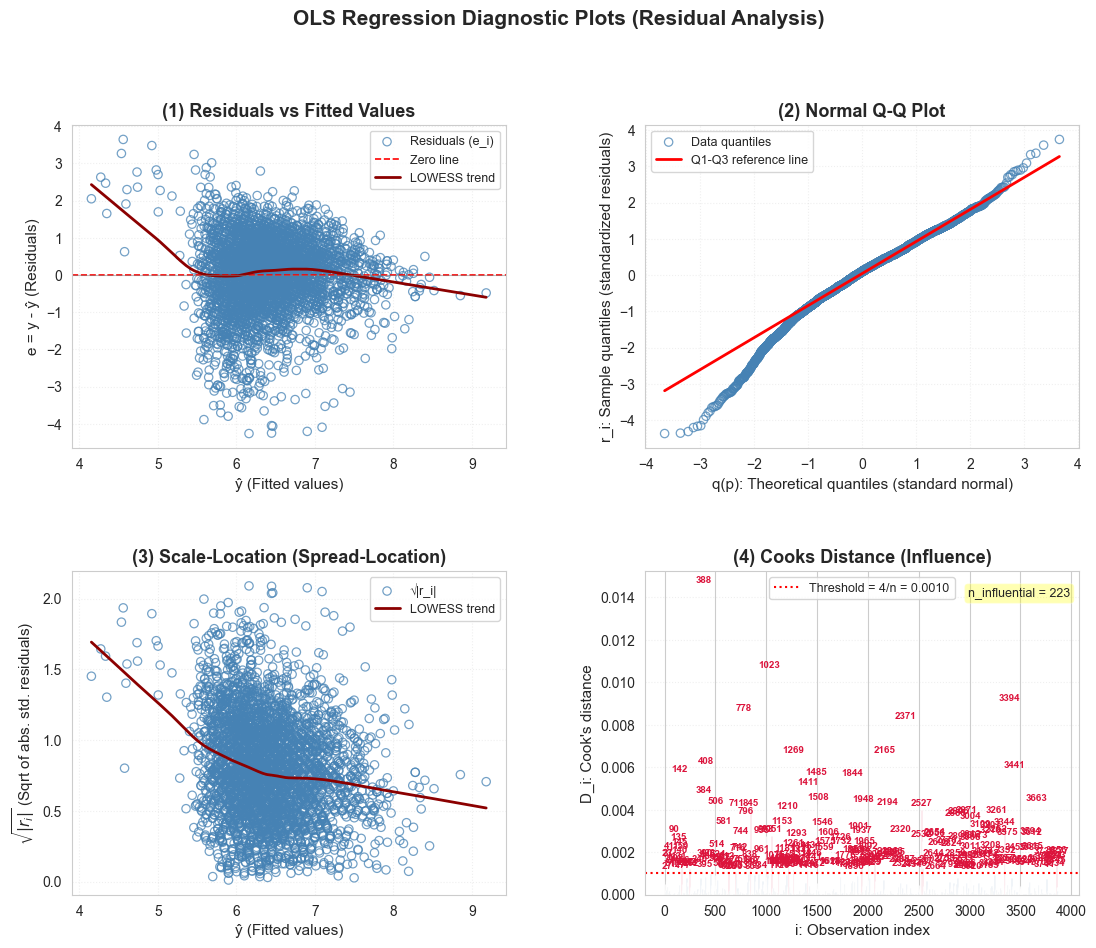

In [43]:
from part1utils.residual_analysis import residual_plots
import numpy as np
from summary_utils import dataframe_to_matrix
from statsmodels.api import add_constant

# ── Chuẩn bị đầu vào ──────────────────────────────────────────────────────────
X_train_sel_const = np.array(
    dataframe_to_matrix(add_constant(train_encoded[selected_features]))
)
y_train_raw = [float(x) for x in train_encoded['imdb_score'].tolist()]

# ── Flatten beta_short về 1D nếu đang là 2D ───────────────────────────────────
beta_flat = [
    float(b[0]) if isinstance(b, (list, tuple)) else float(b)
    for b in beta_short
]

# ── Vẽ 4 biểu đồ phân tích phần dư ───────────────────────────────────────────
fig = residual_plots(
    X        = X_train_sel_const.tolist(),
    y        = y_train_raw,
    beta_hat = beta_flat,       # ← dùng beta đã flatten
)

## Phân tích biểu đồ phần dư — OLS Chọn Biến

Sau khi ước lượng mô hình tốt nhất, ta tiến hành kiểm tra phần dư thông qua bốn biểu đồ chẩn đoán
để đánh giá mức độ thỏa mãn các giả định thống kê cơ bản của OLS.

---

### (1) Residuals vs Fitted Values — Kiểm tra Linearity & Homoscedasticity

Biểu đồ này kiểm tra hai giả định quan trọng: **tính tuyến tính** và **đồng phương sai**.
Nếu mô hình phù hợp, các điểm phần dư phải phân bố ngẫu nhiên quanh đường $e = 0$,
không tạo thành dạng cong hoặc dạng sóng; đồng thời độ rộng phân tán của phần dư phải
tương đối ổn định dọc theo trục $\hat{y}$, không tạo hình phễu.

**Quan sát:**
- Đường LOWESS trend có hình chữ **S rõ rệt** — đi từ giá trị dương ($\approx +2.5$)
tại $\hat{y} \approx 4$, cắt đường $e = 0$ tại $\hat{y} \approx 6$, rồi xuống âm khi $\hat{y} > 8$
- Mức uốn cong của LOWESS **lớn và có hệ thống**, khác hẳn với dao động ngẫu nhiên
- Độ phân tán của phần dư thu hẹp dần khi $\hat{y}$ tăng, tạo thành dạng **hình phễu ngược**

**Kết luận:** Vi phạm cả hai giả định:
- **Linearity**: LOWESS có xu hướng phi tuyến hình chữ S — mô hình tuyến tính chưa
nắm bắt được toàn bộ cấu trúc của dữ liệu IMDb score.
- **Homoscedasticity**: Độ phân tán phần dư không đồng đều theo $\hat{y}$
— có dấu hiệu của hiện tượng **heteroscedasticity**.

---

### (2) Normal Q-Q Plot — Kiểm tra Normality

Biểu đồ này kiểm tra giả thuyết phần dư chuẩn hóa có phân phối gần chuẩn hay không.
Nếu phần dư tuân theo phân phối chuẩn, các điểm dữ liệu sẽ nằm gần đường tham chiếu.
Khi các điểm lệch mạnh ở hai đuôi, phần dư có thể có đuôi dày hoặc chứa các outliers.

**Quan sát:**
- Vùng trung tâm $[-2, +2]$: các điểm bám **khá sát** đường tham chiếu màu đỏ
→ phần lớn phần dư ở vùng giữa tuân thủ tốt phân phối chuẩn lý thuyết
- Đuôi trái ($q < -2$): các điểm **lệch xuống dưới** đường tham chiếu — đuôi trái dày hơn chuẩn
- Đuôi phải ($q > 2$): các điểm **lệch lên trên** đường tham chiếu — đuôi phải dày hơn chuẩn
- Xuất hiện **cấu trúc dạng chữ S** ở hai đuôi

**Kết luận:** Giả định Normality được thỏa mãn **ở mức chấp nhận được**.
Phần dư có hiện tượng **heavy-tailed** (leptokurtic) — hai đuôi dày hơn so với phân phối
chuẩn lý tưởng, chủ yếu do một số outliers có độ lệch lớn. Tuy nhiên, sai lệch này chỉ
xuất hiện ở vùng đuôi và không phá vỡ cấu trúc chính của phân phối, nên các kiểm định
thống kê vẫn có thể thực hiện với độ tin cậy hợp lý.

---

### (3) Scale-Location Plot — Kiểm tra Homoscedasticity

Biểu đồ Scale-Location nhạy hơn biểu đồ (1) trong việc phát hiện phương sai thay đổi.
Nếu mô hình có đồng phương sai, đường LOWESS nên tương đối phẳng và độ phân tán
của các điểm không nên tăng hoặc giảm có hệ thống theo $\hat{y}$.

**Quan sát:**
- Đường LOWESS dốc **giảm mạnh và có hệ thống** từ trái sang phải:
$\sqrt{|r_i|} \approx 1.7$ tại $\hat{y} \approx 4$ xuống còn $\approx 0.5$ tại $\hat{y} \approx 9$,
chênh lệch khoảng **1.2** — lớn hơn nhiều so với mức dao động ngẫu nhiên
- Độ phân tán của các điểm cũng **thu hẹp rõ rệt** khi $\hat{y}$ tăng
- Biểu đồ có dạng **hình phễu ngược** — trái rộng, phải hẹp

**Kết luận:** Vi phạm rõ ràng giả định **Homoscedasticity**. Khác với dữ liệu mô phỏng
trong báo cáo lý thuyết — nơi LOWESS chỉ dốc nhẹ với biên độ $\approx 0.37$ và không
đủ mạnh để kết luận phương sai thay đổi — ở đây biên độ thay đổi lên đến $\approx 1.2$,
là bằng chứng rõ ràng của hiện tượng **heteroscedasticity**. Điều này có thể ảnh hưởng
đến tính hiệu quả của ước lượng OLS.

---

### (4) Cook's Distance — Kiểm tra Influential Points

Cook's Distance xác định các quan sát có ảnh hưởng lớn đến hệ số ước lượng $\hat{\beta}$.
Một quan sát có $D_i$ lớn thường vừa có phần dư lớn, vừa có leverage cao.
Ngưỡng tham chiếu được sử dụng là $D_i > 4/n$.

**Quan sát:**
- Ngưỡng $4/n = 0.0010$ — rất thấp do tập train có $n \approx 4000$ quan sát
- Có **nhiều quan sát vượt ngưỡng** $4/n$, nổi bật là: **388, 1023, 778, 3394, 2371,...**
với $D_i$ cao nhất đạt $\approx 0.014$
- Tuy nhiên, **không có quan sát nào** đạt mức ngưỡng nghiêm trọng $D_i > 0.5$ hoặc $D_i > 1.0$

**Kết luận:** Có nhiều điểm vượt ngưỡng tương đối $4/n$, nhưng tương tự như nhận xét
trong báo cáo lý thuyết, giá trị $D_i$ lớn nhất vẫn thấp xa so với các ngưỡng nghiêm trọng.
Do đó, các điểm này chỉ nên được xem là **điểm cần chú ý**, không phải điểm làm méo mó
hệ thống mô hình. Mô hình OLS Chọn Biến được đánh giá là **ổn định**, các hệ số
$\hat{\beta}$ không bị chi phối bởi một điểm dữ liệu đơn lẻ.

---

### Tổng kết

| Giả định | Biểu đồ | Kết quả |
|:---------|:--------|:--------|
| **Linearity** | (1) Residuals vs Fitted | Vi phạm — LOWESS có cấu trúc phi tuyến hình chữ S |
| **Normality** | (2) Normal Q-Q Plot | Chấp nhận được — heavy-tailed nhẹ ở hai đuôi |
| **Homoscedasticity** | (3) Scale-Location | Vi phạm — phương sai giảm mạnh theo $\hat{y}$ |
| **Influential points** | (4) Cook's Distance | Nhiều điểm vượt $4/n$ nhưng không đạt ngưỡng nghiêm trọng |

> **Nhận xét chung:** Mô hình OLS Chọn Biến vi phạm hai giả định quan trọng là
> **Linearity** và **Homoscedasticity**. Điều này phù hợp với $R^2 \approx 0.1757$ —
> mô hình tuyến tính đơn thuần chưa đủ khả năng mô tả toàn bộ mối quan hệ giữa
> các đặc trưng và IMDb score. Giả định **Normality** được thỏa mãn ở mức chấp nhận
> được, và không có điểm dữ liệu đơn lẻ nào gây ảnh hưởng nghiêm trọng đến mô hình.
> Để cải thiện, có thể xem xét **biến đổi biến mục tiêu**, bổ sung **đặc trưng phi tuyến**,
> hoặc chuyển sang các mô hình phức tạp hơn trong các nghiên cứu tiếp theo.